# OBJECTIVE

This notebook performs exploratory data analysis (EDA) and statistical testing on the Ludo dataset generated from a 4-token-per-player Ludo simulation.

## Background
Ludo is a classic board game where 4 players each control 4 tokens. Players roll a 6-sided die each turn; rolling a 6 unlocks a token from the home yard and grants an extra turn. Tokens travel 56 squares before entering the finish zone. If a token lands on an opponent's square, the opponent's token is sent back to home. The first player to move all 4 tokens to the finish wins.

The dataset captures every move made across multiple simulated games, recording the full board state before and after each move, plus contextual features such as dice roll, token positions, token-state counts per player, and the winner label.

## Notebook Workflow
| Step | Section | Description |
|---|---|---|
| 1 | Data Loading & Validation | Locate the latest CSV, enforce the 12-column schema, preview the data |
| 2 | Descriptive Statistics | Summarise central tendency, spread, and completeness |
| 3 | Data Quality Checks | Missing values (structural vs. problematic), duplicates, and outliers |
| 4 | Distribution Exploration | Histograms, KDE, pairplot, countplots, and grouped boxplots |
| 5 | Correlation Analysis | Spearman correlation heatmap across numeric variables |
| 6a | Global Normality Testing | Shapiro-Wilk / D'Agostino-Pearson for each numeric variable |
| 6b | Grouped Normality Testing | Same tests per category level, per numeric variable |
| 6c | Kruskal-Wallis Test | Compare numeric variables across the 4 player groups |
| 6d | Mann-Whitney U Test | Compare numeric variables between winner and non-winner groups |
| 7 | Conclusion | Summarise findings and implications for feature engineering and modelling |

## Goals
- Load and validate the latest generated dataset from the 4-token-per-player Ludo simulation.
- Assess data quality (missing values, duplicates, and outliers) across all 12 columns.
- Distinguish structural missingness (e.g., no legal move, `Token_Moved = 0`) from problematic missingness.
- Apply a cleaning rule for analysis: if missingness does not affect core analysis columns, remove missing rows for complete-case modelling tables.
- Explore variable distributions and relationships using visualisations for token-state features (`Token_Moved`, `Position_Before`, `Position_After`, `Tokens_Home`, `Tokens_Active`, `Tokens_Finished`, `Captured_Opponent`).
- Evaluate statistical assumptions (normality) globally and within player groups.
- Apply non-parametric tests (Kruskal-Wallis and Mann-Whitney U) where appropriate.
- Highlight group concentration zones (IQR, median, and peak) in significant test plots for clearer interpretation.
- Produce interpretable outputs to guide feature engineering and model development.

## Step 1 — Data Loading & Validation

### Why this step?
Before any analysis can begin, the correct dataset must be located and loaded into memory. Because this notebook can be run from different working directories (the notebook's own folder or the project root), multiple candidate paths are checked in priority order — preferring the most recently cleaned output over the raw source.

### Libraries used
| Library | Role |
|---|---|
| `pathlib.Path` | Platform-independent file path resolution and existence checks |
| `pandas` | DataFrame operations, CSV I/O, and descriptive statistics |
| `numpy` | Numerical arrays, `NaN` handling, and histogram computation |
| `matplotlib.pyplot` | Low-level plot construction, layout, and display |
| `seaborn` | High-level statistical visualisation built on Matplotlib |
| `pingouin` | Statistical tests: normality, Kruskal-Wallis, and Mann-Whitney U |

### Schema — the 12 expected columns
| Column | Type | Description |
|---|---|---|
| `Game_ID` | int | Unique game identifier |
| `Turn` | int | Sequential turn number within a game |
| `Player` | str | Player label (`Player_1` – `Player_4`) |
| `Dice_Roll` | int | Outcome of the 6-sided die roll (1–6) |
| `Token_Moved` | int | Token selected for movement (1–4); `0` = no legal move available |
| `Position_Before` | float | Board position before the move (0 = home yard, 1–56 = board, 57 = finished; `NaN` when no move) |
| `Position_After` | float | Board position after the move (same encoding; `NaN` when no move) |
| `Tokens_Home` | int | Number of the player's tokens still in the home yard after the move |
| `Tokens_Active` | int | Number of the player's tokens currently on the board after the move |
| `Tokens_Finished` | int | Number of the player's tokens that have reached the finish zone after the move |
| `Captured_Opponent` | int | `1` if an opponent token was sent back to home this turn, `0` otherwise |
| `Is_Winner` | int | `1` for every move belonging to the game winner, `0` otherwise |

### What to check in the output
- The printed path confirms the correct file was found and which source was used.
- The shape confirms the expected number of rows and exactly 12 columns.
- `df.head()` provides a quick sanity check that values are in valid ranges and the column order matches the schema.
- If `missing_cols` is non-empty, the cell raises a `ValueError` early rather than silently producing incorrect results downstream.

In [1]:
# Importing libraries and loading the latest ludo dataset
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg

EXPECTED_COLUMNS = [
    "Game_ID", "Turn", "Player", "Dice_Roll", "Token_Moved",
    "Position_Before", "Position_After", "Tokens_Home",
    "Tokens_Active", "Tokens_Finished", "Captured_Opponent", "Is_Winner",
]

# Prefer newest generated cleaned/raw outputs and support notebook/root execution
candidate_paths = [
    Path("data file/Raw_Data/ludo_dataset_cleaned.csv"),
    Path("data file/Raw_Data/ludo_dataset.csv"),
    Path("../data file/Raw_Data/ludo_dataset_cleaned.csv"),
    Path("../data file/Raw_Data/ludo_dataset.csv"),
    Path("data file/Clean_Data/ludo_dataset_cleaned.csv"),
    Path("../data file/Clean_Data/ludo_dataset_cleaned.csv"),
]

dataset_path = next((p for p in candidate_paths if p.exists()), None)
if dataset_path is None:
    raise FileNotFoundError("Could not find a Ludo dataset CSV in expected locations.")

df = pd.read_csv(dataset_path)

missing_cols = [c for c in EXPECTED_COLUMNS if c not in df.columns]
if missing_cols:
    raise ValueError(f"Dataset schema mismatch. Missing columns: {missing_cols}")

df = df[EXPECTED_COLUMNS].copy()

print(f"Loaded dataset from: {dataset_path}")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Loaded dataset from: ../data file/Raw_Data/ludo_dataset_cleaned.csv
Shape: 11104 rows x 12 columns


,Game_ID,Turn,Player,Dice_Roll,Token_Moved,Position_Before,Position_After,Tokens_Home,Tokens_Active,Tokens_Finished,Captured_Opponent,Is_Winner
0,0,1,Red,6,1,0.0,1.0,3,1,0,0,0
1,0,2,Red,1,1,1.0,2.0,3,1,0,0,0
2,0,3,Green,6,3,0.0,1.0,3,1,0,0,0
3,0,4,Green,2,3,1.0,3.0,3,1,0,0,0
4,0,5,Yellow,2,0,NaN,NaN,4,0,0,0,0


## Step 2 — Descriptive Statistics

### Why this step?
`df.describe(include='all')` provides a compact, multi-faceted snapshot of every column in a single call. It is the fastest way to spot data quality issues — impossible values, unexpected ranges, or columns with unusually low cardinality — before committing to deeper analysis.

### What each row of the summary means
| Row | Numeric columns | Categorical / object columns |
|---|---|---|
| `count` | Non-null observations | Non-null observations |
| `mean` | Arithmetic average | — |
| `std` | Standard deviation (spread around the mean) | — |
| `min` / `max` | Smallest / largest observed value | — |
| `25%`, `50%`, `75%` | Lower quartile, median, upper quartile | — |
| `unique` | — | Number of distinct values |
| `top` | — | Most frequent value (mode) |
| `freq` | — | Count of the most frequent value |

### What to look for in this dataset
- **`Dice_Roll`**: should range 1–6 with `mean` ≈ 3.5 (uniform distribution).
- **`Token_Moved`**: values 0–4; high frequency of `0` indicates many turns where no legal move was available.
- **`Position_Before` / `Position_After`**: valid range 0–57; any value outside this range signals a simulation bug.
- **`Tokens_Home` + `Tokens_Active` + `Tokens_Finished`**: these three counts must sum to exactly 4 for every row (each player has 4 tokens total).
- **`Captured_Opponent`** and **`Is_Winner`**: binary 0/1; `mean` gives the event rate (e.g., capture rate per turn).
- **`count` vs. total rows**: differences between `count` and the total row count reveal per-column missing values, previewing the analysis in Step 3a.

In [2]:
df.describe(include='all')

,Game_ID,Turn,Player,Dice_Roll,Token_Moved,Position_Before,Position_After,Tokens_Home,Tokens_Active,Tokens_Finished,Captured_Opponent,Is_Winner
count,11104.000000,11104.000000,11104,11104.000000,11104.000000,8556.000000,8556.000000,11104.000000,11104.000000,11104.000000,11104.000000,11104.000000
unique,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Yellow,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,2799,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,12.412374,221.648955,NaN,3.529449,1.931646,27.702665,30.532258,2.226135,0.746938,1.026927,0.020353,0.258015
std,7.779826,136.878921,NaN,1.719823,1.436679,19.192122,18.745258,1.062539,0.434786,0.989950,0.141211,0.437562
min,0.000000,1.000000,NaN,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,107.000000,NaN,2.000000,1.000000,10.000000,13.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,13.000000,214.000000,NaN,4.000000,2.000000,27.000000,30.000000,2.000000,1.000000,1.000000,0.000000,0.000000
75%,19.000000,323.000000,NaN,5.000000,3.000000,46.000000,50.000000,3.000000,1.000000,2.000000,0.000000,1.000000


## Step 3a — Missing Value Assessment

### Why this step?
Missing data can arise for two fundamentally different reasons in this dataset, and they must not be treated identically:

| Type | Cause | Columns affected | Correct treatment |
|---|---|---|---|
| **Structural missingness** | Player had no legal move (`Token_Moved = 0`), so no token was actually moved | `Position_Before`, `Position_After` | **Do not impute** — the `NaN` is meaningful. Drop these rows only for analyses that specifically require position data |
| **Problematic missingness** | Data generation error or simulation bug | Any other column | Investigate; consider row removal or re-simulation |

### Interpretation guide
- A large `NaN` count in **`Position_Before`** and **`Position_After`** is expected and corresponds to turns where `Token_Moved == 0`.
- Cross-check: `df[df['Token_Moved'] == 0].shape[0]` should equal the `NaN` count in `Position_Before` and `Position_After`.
- Any `NaN`s in **`Dice_Roll`**, **`Player`**, **`Turn`**, **`Tokens_Home`**, **`Tokens_Active`**, **`Tokens_Finished`**, **`Captured_Opponent`**, or **`Is_Winner`** are unexpected and warrant investigation before proceeding.

### Connection to the next steps
- The structural `NaN`s are preserved when saving the cleaned file (Step 3d) so that downstream analyses can handle them explicitly.
- Complete-case analyses (e.g., position-based visualisations) simply drop `NaN` rows at the point of use rather than globally removing them.

In [16]:
missing_summary = df.isnull().sum()
print("Missing values per column:")
display(missing_summary.to_frame("missing_count"))

# Structural-missingness cross-check for no-move turns
no_move_count = (df['Token_Moved'] == 0).sum()
pos_before_nan = df['Position_Before'].isna().sum()
pos_after_nan = df['Position_After'].isna().sum()

print(f"No-move turns (Token_Moved == 0): {no_move_count}")
print(f"NaN count in Position_Before: {pos_before_nan}")
print(f"NaN count in Position_After: {pos_after_nan}")
print(
    "Structural missingness check:",
    "PASS" if (no_move_count == pos_before_nan == pos_after_nan) else "CHECK NEEDED"
)

Missing values per column:


,missing_count
Game_ID,0
Turn,0
Player,0
Dice_Roll,0
Token_Moved,0
Position_Before,2548
Position_After,2548
Tokens_Home,0
Tokens_Active,0
Tokens_Finished,0


No-move turns (Token_Moved == 0): 2548
NaN count in Position_Before: 2548
NaN count in Position_After: 2548
Structural missingness check: PASS


## Step 3b — Duplicate Row Detection

### Why this step?
Exact duplicate rows silently bias all downstream analyses by artificially inflating the frequency of certain game states or turn sequences. Inflated frequencies distort summary statistics, distribution plots, correlation values, and hypothesis test results. In a simulation context, duplicates most commonly arise from:

- Accidental double-writing during CSV export (e.g., appending the same batch twice).
- Multiple simulation runs being concatenated without deduplication.
- Logging the same game event more than once due to a simulation loop error.

### Interpretation guide
- **0 duplicates** is the ideal result, confirming every row represents a unique game event.
- **Any duplicates found** should be investigated further:
  - Are they identical `(Game_ID, Turn, Player)` triplets? → Genuine data error; drop with `df.drop_duplicates(inplace=True)`.
  - Are they coincidentally identical board states across *different* games? → Acceptable; may not need removal.
- If duplicates are removed, the cleaning cell (Step 3d) should be re-run to persist the deduplicated version.

### Context
Because each row encodes a specific `(Game_ID, Turn, Player)` combination that uniquely identifies one move in one game, true duplicates are a strong signal of a simulation or export fault rather than a natural game repetition.

In [17]:
exact_duplicate_rows = int(df.duplicated().sum())
key_duplicate_rows = int(df.duplicated(subset=['Game_ID', 'Turn', 'Player']).sum())

print(f"Exact duplicate rows: {exact_duplicate_rows}")
print(f"Duplicate (Game_ID, Turn, Player) rows: {key_duplicate_rows}")

Exact duplicate rows: 0
Duplicate (Game_ID, Turn, Player) rows: 0


## Step 3c — Outlier Detection via Boxplots

### Why this step?
Boxplots are the standard first-pass tool for visualising the spread of numeric variables and flagging extreme values (outliers). Detecting outliers early prevents them from distorting summary statistics, normality test results, correlation values, and model training.

### How to read the boxplots
| Element | Meaning |
|---|---|
| Box lower edge | 25th percentile (Q1) |
| Box centre line | Median (Q2) |
| Box upper edge | 75th percentile (Q3) |
| Whiskers | Extend to Q1 − 1.5 × IQR and Q3 + 1.5 × IQR |
| Individual points | Observations beyond the whisker range (outliers) |

### What to expect for each variable
| Variable | Expected behaviour |
|---|---|
| `Dice_Roll` | Near-uniform 1–6; no extreme outliers expected |
| `Turn` | Right-skewed; long games produce high turn counts; high-turn outliers are genuine |
| `Token_Moved` | Discrete 0–4; no outliers possible |
| `Position_Before` / `Position_After` | Range 0–57; NaN rows (no-move turns) excluded automatically by seaborn |
| `Tokens_Home`, `Tokens_Active`, `Tokens_Finished` | Discrete 0–4; no outliers possible |
| `Captured_Opponent`, `Is_Winner` | Binary 0/1; boxplot confirms range |

### Caution
Outliers in game-state variables (e.g., very high `Turn` values from long games) are likely genuine simulation edge cases — not data errors. Remove only rows that are confirmed artefacts of a logging or simulation fault, never simply because a value is extreme.

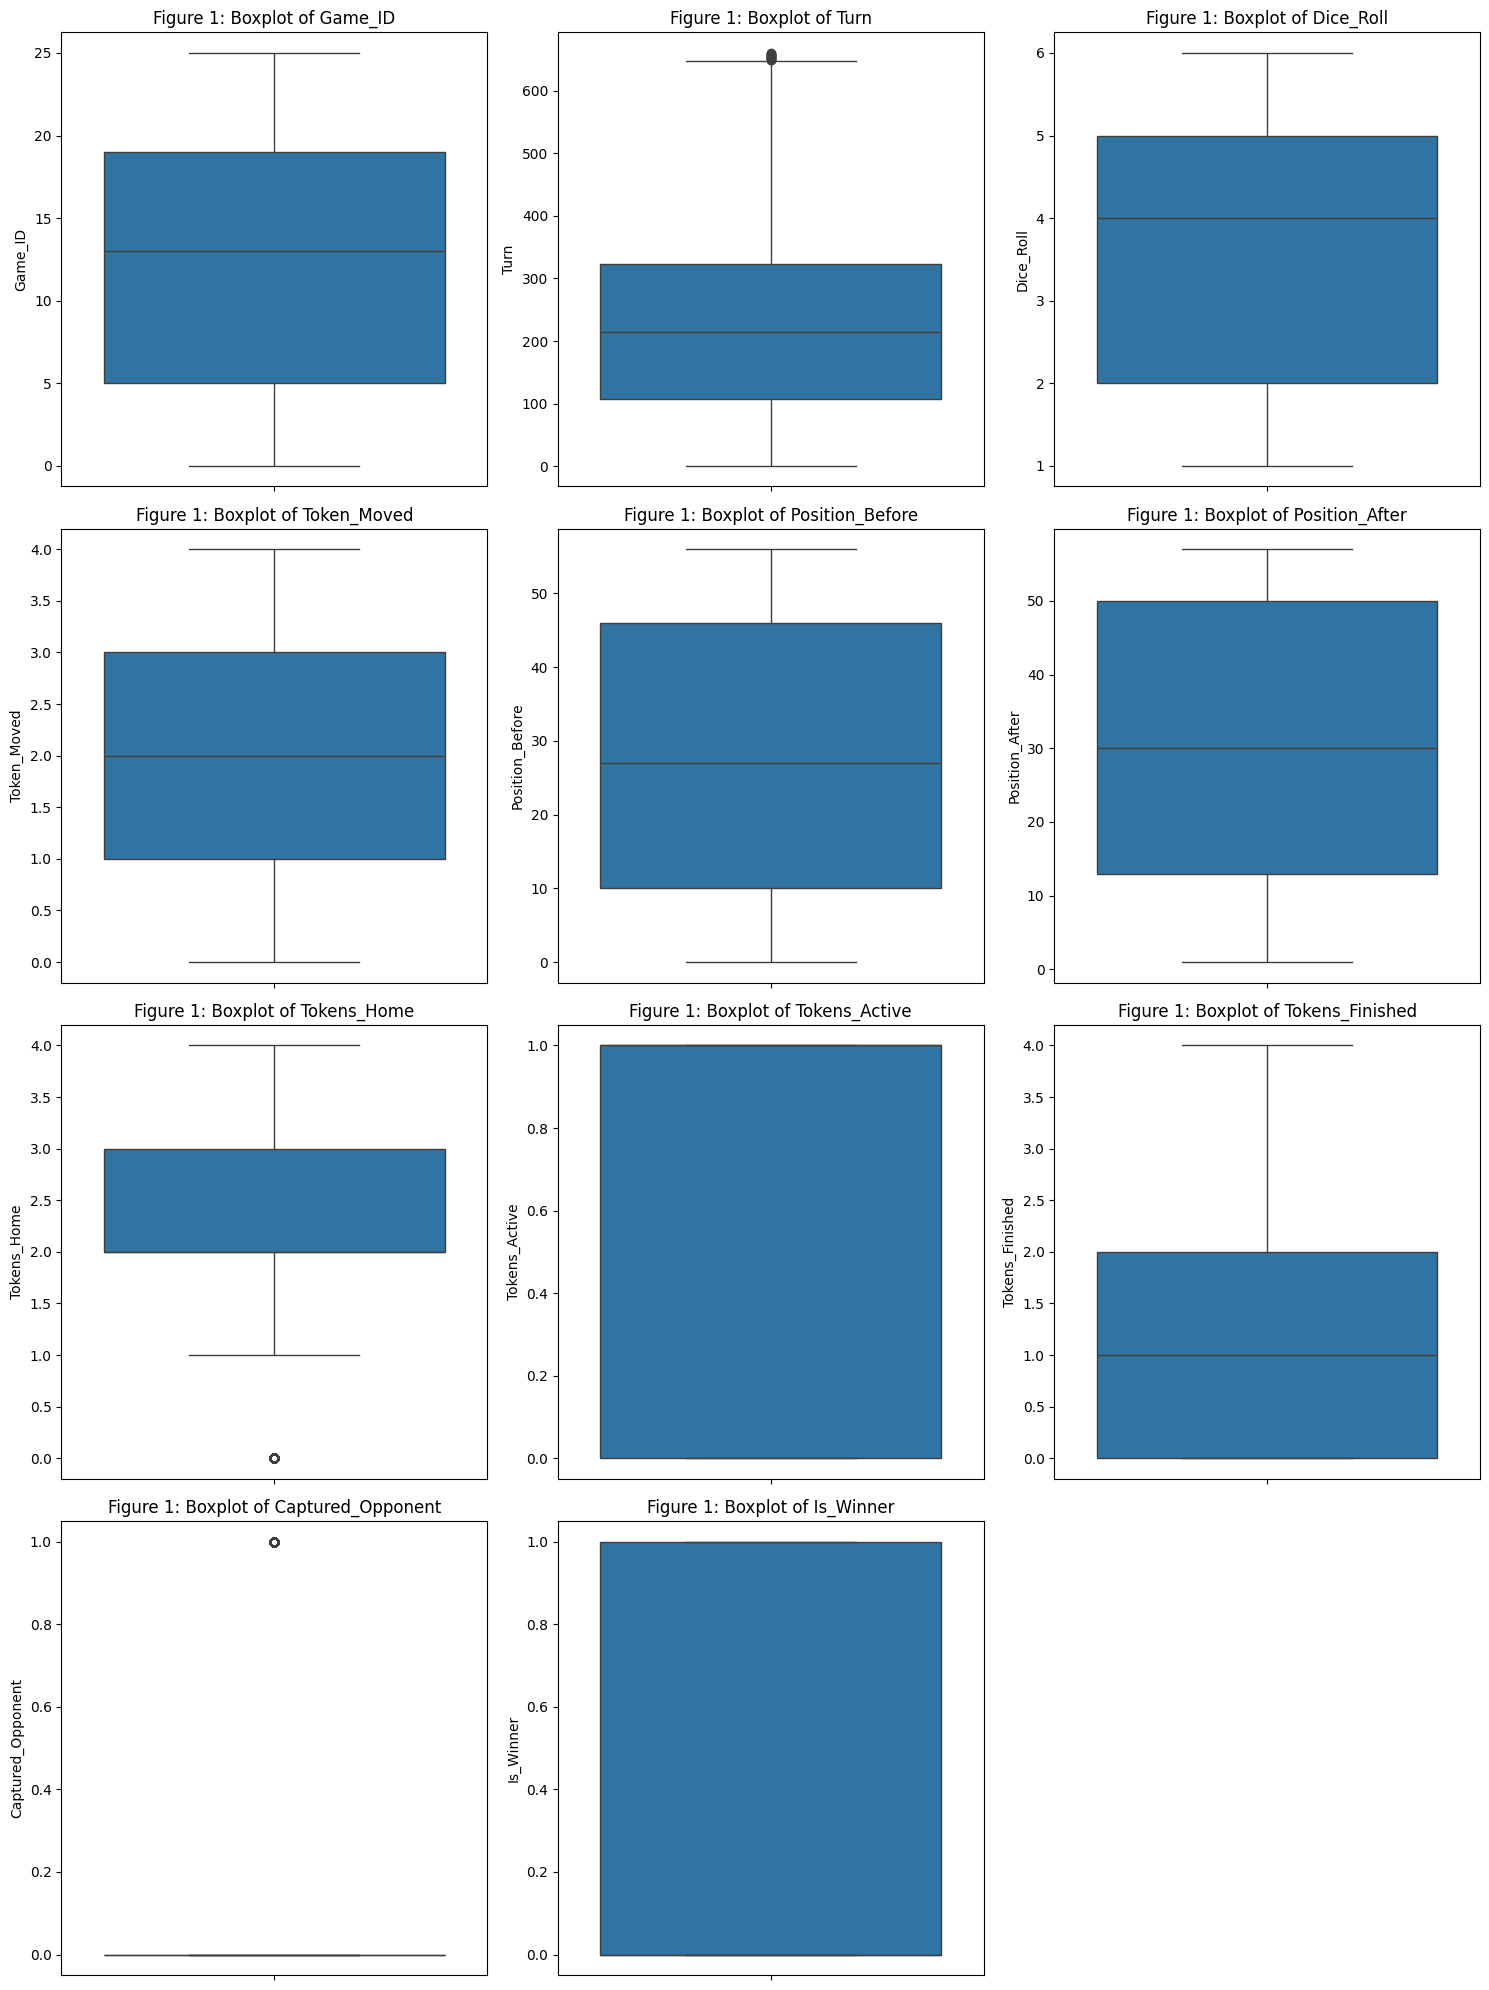

In [5]:
# Checking for outliers in the numeric variables using boxplots
import math

df_num = df.select_dtypes(include=[np.number])
n_cols = 3
n_rows = math.ceil(len(df_num.columns) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(df_num.columns):
    sns.boxplot(y=df_num[col], ax=axes[i])
    axes[i].set_title(f'Figure 1: Boxplot of {col}')

# Hide any unused subplot panels
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


## Step 3d — Save Cleaned Dataset

### Why this step?
Saving a cleaned and validated copy of the working DataFrame at this point ensures:

1. **Reproducibility** — subsequent notebooks (Feature Engineering, Modelling) can load the same schema-enforced dataset without re-running the full simulation or the load-and-validate logic.
2. **Data lineage** — a separate cleaned file keeps the raw source untouched while the analysis operates on a safe, controlled copy.
3. **Convenience** — the file is written to the same directory as the source, making it easy to discover and load with a relative path.

### File output
| Detail | Value |
|---|---|
| Filename | `ludo_dataset_cleaned.csv` |
| Location | Same directory as the source file (`dataset_path.parent`) |
| Format | UTF-8 CSV, no index column (`index=False`) |
| Content | All rows passing schema validation; structural `NaN`s in `Position_Before` and `Position_After` are **preserved** to maintain transparency about no-move turns |

### Important note
If problematic duplicates or out-of-range values were identified in Steps 3a–3c, the corresponding cleanup steps (`drop_duplicates`, row filtering) should be applied to `df` **before** this cell is executed, so the saved file reflects the fully cleaned state.

In [6]:
# Save the cleaned dataset to a new CSV file
cleaned_dataset_path = dataset_path.parent / "ludo_dataset_cleaned.csv"
df.to_csv(cleaned_dataset_path, index=False)


## Step 4a — Distribution Exploration: Histograms & KDE

### Why this step?
While boxplots reveal outliers and spread, histograms combined with KDE (Kernel Density Estimation) curves reveal the full **shape** of each distribution — including modality (single vs. multiple peaks), skewness, and floor/ceiling effects. Understanding distribution shape is essential for choosing appropriate statistical tests later in the workflow.

### How to read the plots
- **Bars (histogram)**: frequency counts within equal-width bins; taller bars = more observations in that value range.
- **KDE curve**: smoothed, continuous estimate of the probability density; peaks indicate high-concentration regions.
- **Right skew**: most mass at low values with a long right tail (common for `Turn`, `Captured_Opponent`).
- **Left skew**: most mass at high values; less common in this dataset.
- **Bimodal / multimodal**: two or more distinct peaks, suggesting sub-populations (e.g., `Position_Before` may spike at 0 for home tokens and at 57 for finished tokens).

### Expected distribution shapes
| Variable | Expected shape | Reason |
|---|---|---|
| `Dice_Roll` | Approximately uniform (flat) | Each value 1–6 is equally likely |
| `Token_Moved` | Discrete spikes at 1–4; possible spike at 0 | Turn structure; 0 only when no legal move |
| `Position_Before` | Spikes at 0 (home) and 57 (finish); roughly flat across 1–56 | Tokens start at home and accumulate at finish |
| `Turn` | Right-skewed | Most games resolve within a moderate number of turns; long games are outliers |
| `Tokens_Finished` | Right-skewed, spike at 0 early in games | Tokens finish incrementally; most turns occur before any token finishes |
| `Captured_Opponent` | Heavily right-skewed | Captures are relatively rare events |

### Link to the next steps
Skewed, bimodal, or bounded distributions almost always **fail normality tests** (Step 6a). This visual evidence pre-justifies the use of non-parametric statistical methods applied in Steps 6c and 6d.

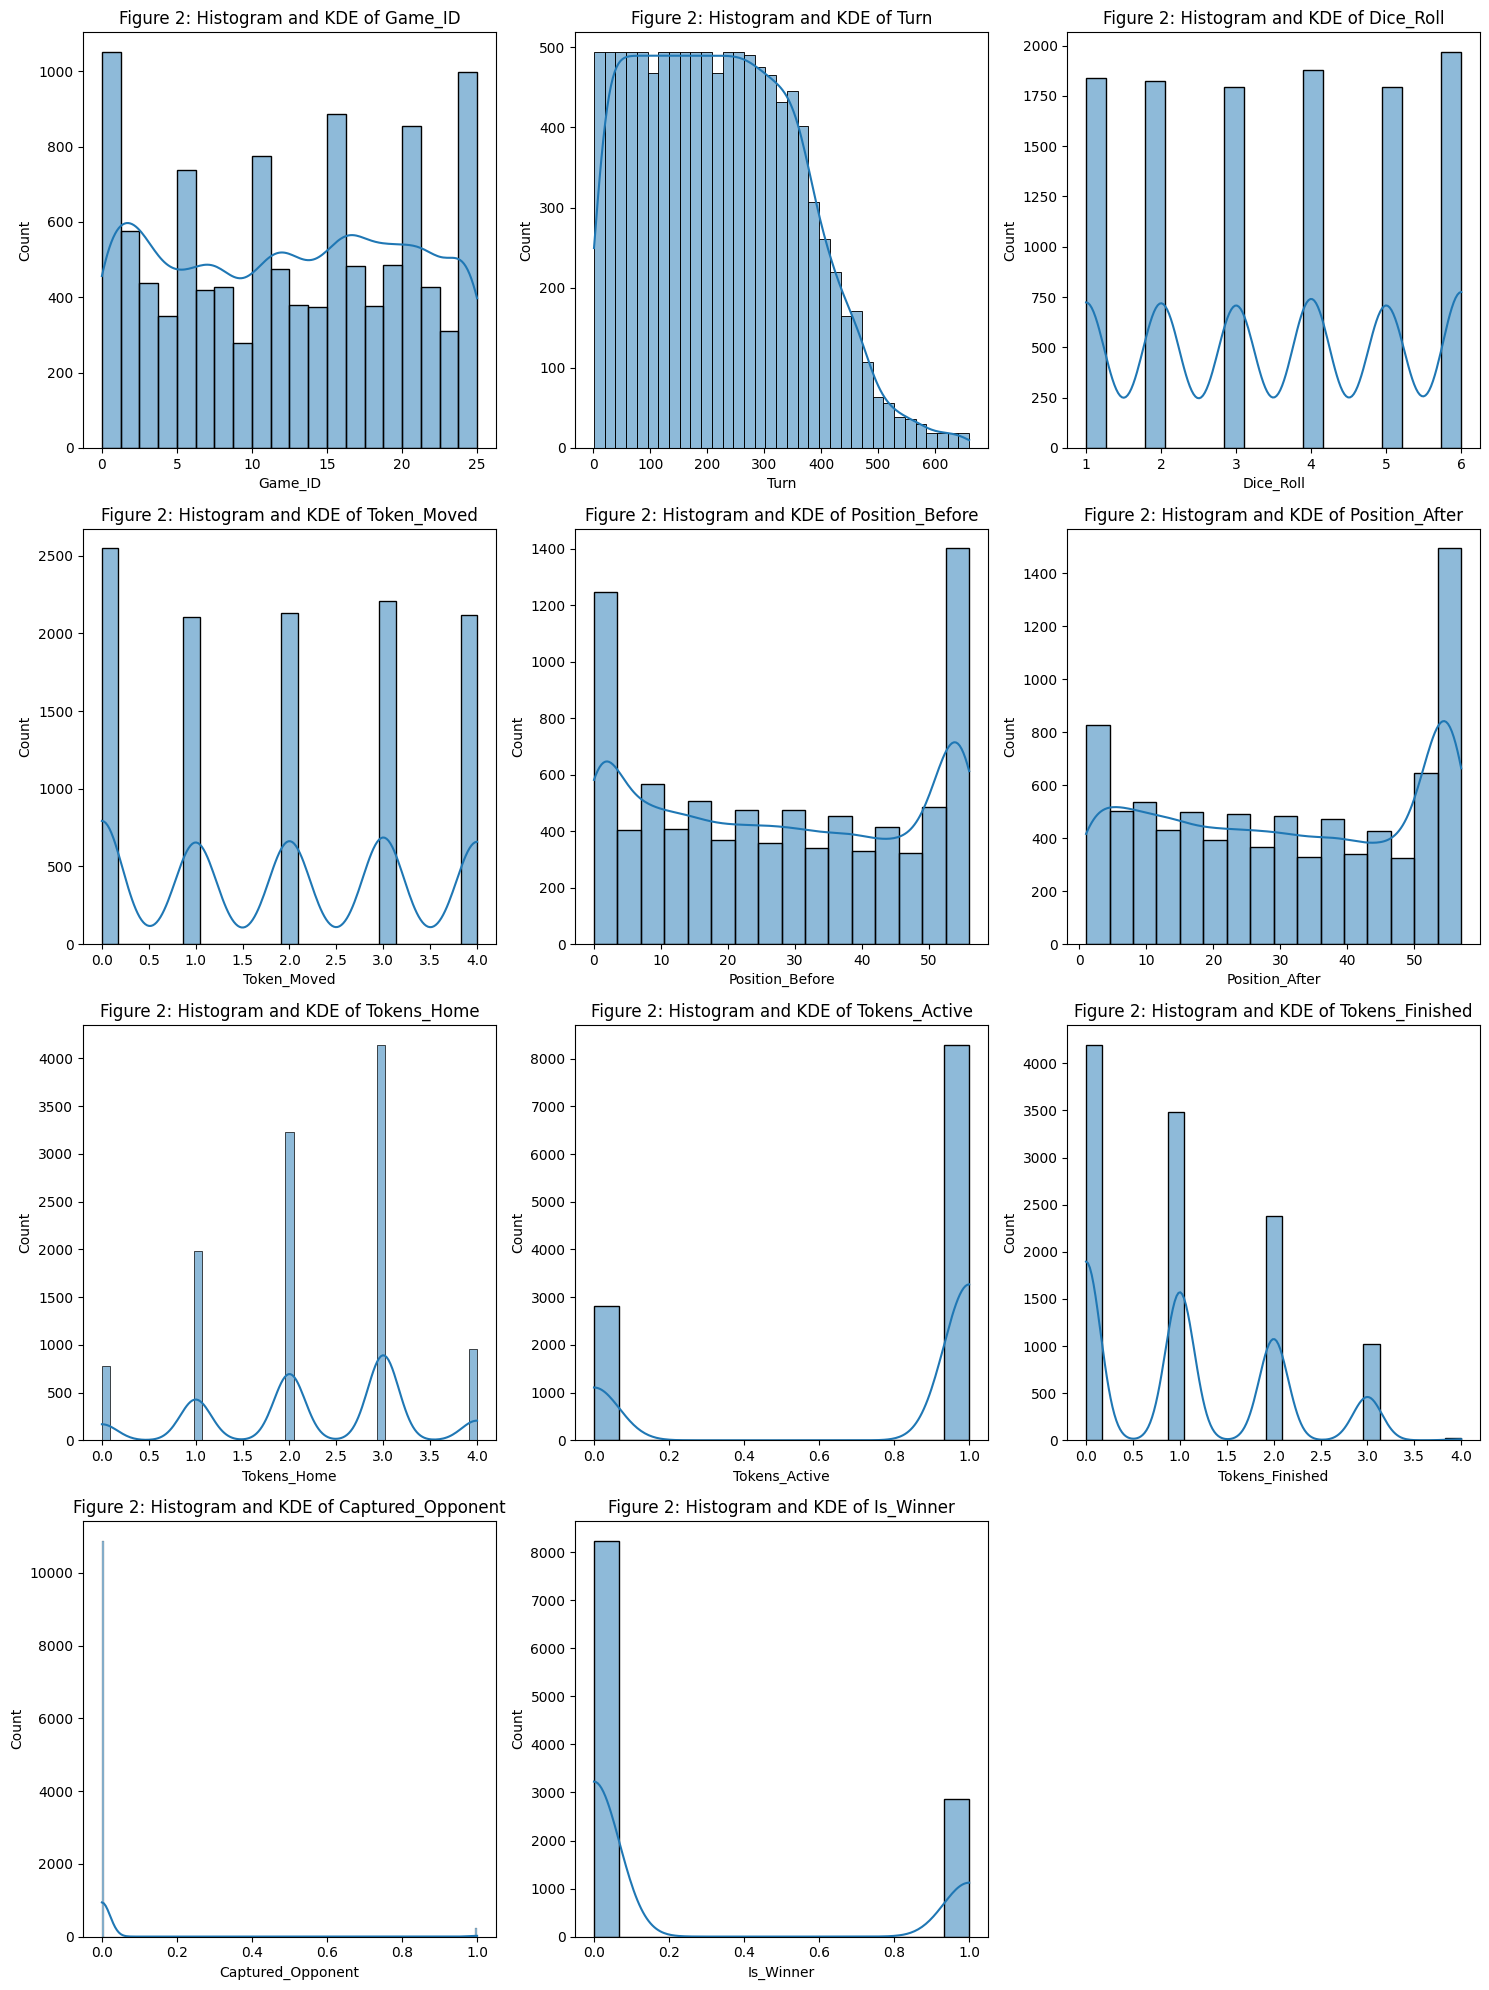

In [7]:
# Visualize the numeric variables using histograms and KDE plots
import math

df_num = df.select_dtypes(include=[np.number])
n_cols = 3
n_rows = math.ceil(len(df_num.columns) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(df_num.columns):
    sns.histplot(df_num[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Figure 2: Histogram and KDE of {col}')

# Hide any unused subplot panels
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


## Step 4b — Pairwise Relationship Exploration: Pairplot

### Why this step?
A pairplot (scatter matrix with regression lines) simultaneously displays **all pairwise bivariate relationships** among numeric variables. This reveals linear or monotonic associations, potential collinearity between predictors, cluster structure in discrete variables, and leverage points that disproportionately influence regression fits.

### How to read the plot
- **Off-diagonal panels**: scatter plot of the column on the X-axis vs. the column on the Y-axis; the regression line shows direction and approximate linearity.
- **Diagonal panels**: KDE of the variable with itself (marginal distribution).
- Steep regression line + tight scatter → strong linear relationship.
- Flat line + wide scatter → weak or no linear relationship.
- Because most variables are integer-valued, scatter panels show banded point clusters rather than smooth clouds — this is normal.

### Expected relationships
| Variable pair | Expected pattern | Reason |
|---|---|---|
| `Tokens_Finished` ↔ `Is_Winner` | Positive | Winners accumulate more finished tokens |
| `Tokens_Home` ↔ `Tokens_Active` | Negative | As tokens leave home, the active count rises |
| `Tokens_Active` ↔ `Tokens_Finished` | Negative | As tokens finish, the active count falls |
| `Position_Before` ↔ `Position_After` | Strong positive | Position changes by at most one die roll per turn |
| `Dice_Roll` ↔ any other variable | Flat / near zero | Dice rolls are independent of game state |

### ⚠️ Performance note
The pairplot size is **k × k**, where `k = len(df_num.columns)` (the number of numeric columns selected in code). On large datasets this cell may take considerable time. If the dataset exceeds ~10,000 rows, consider passing a sample (e.g., `df_num.sample(5000)`) to speed up rendering without sacrificing visual insight.

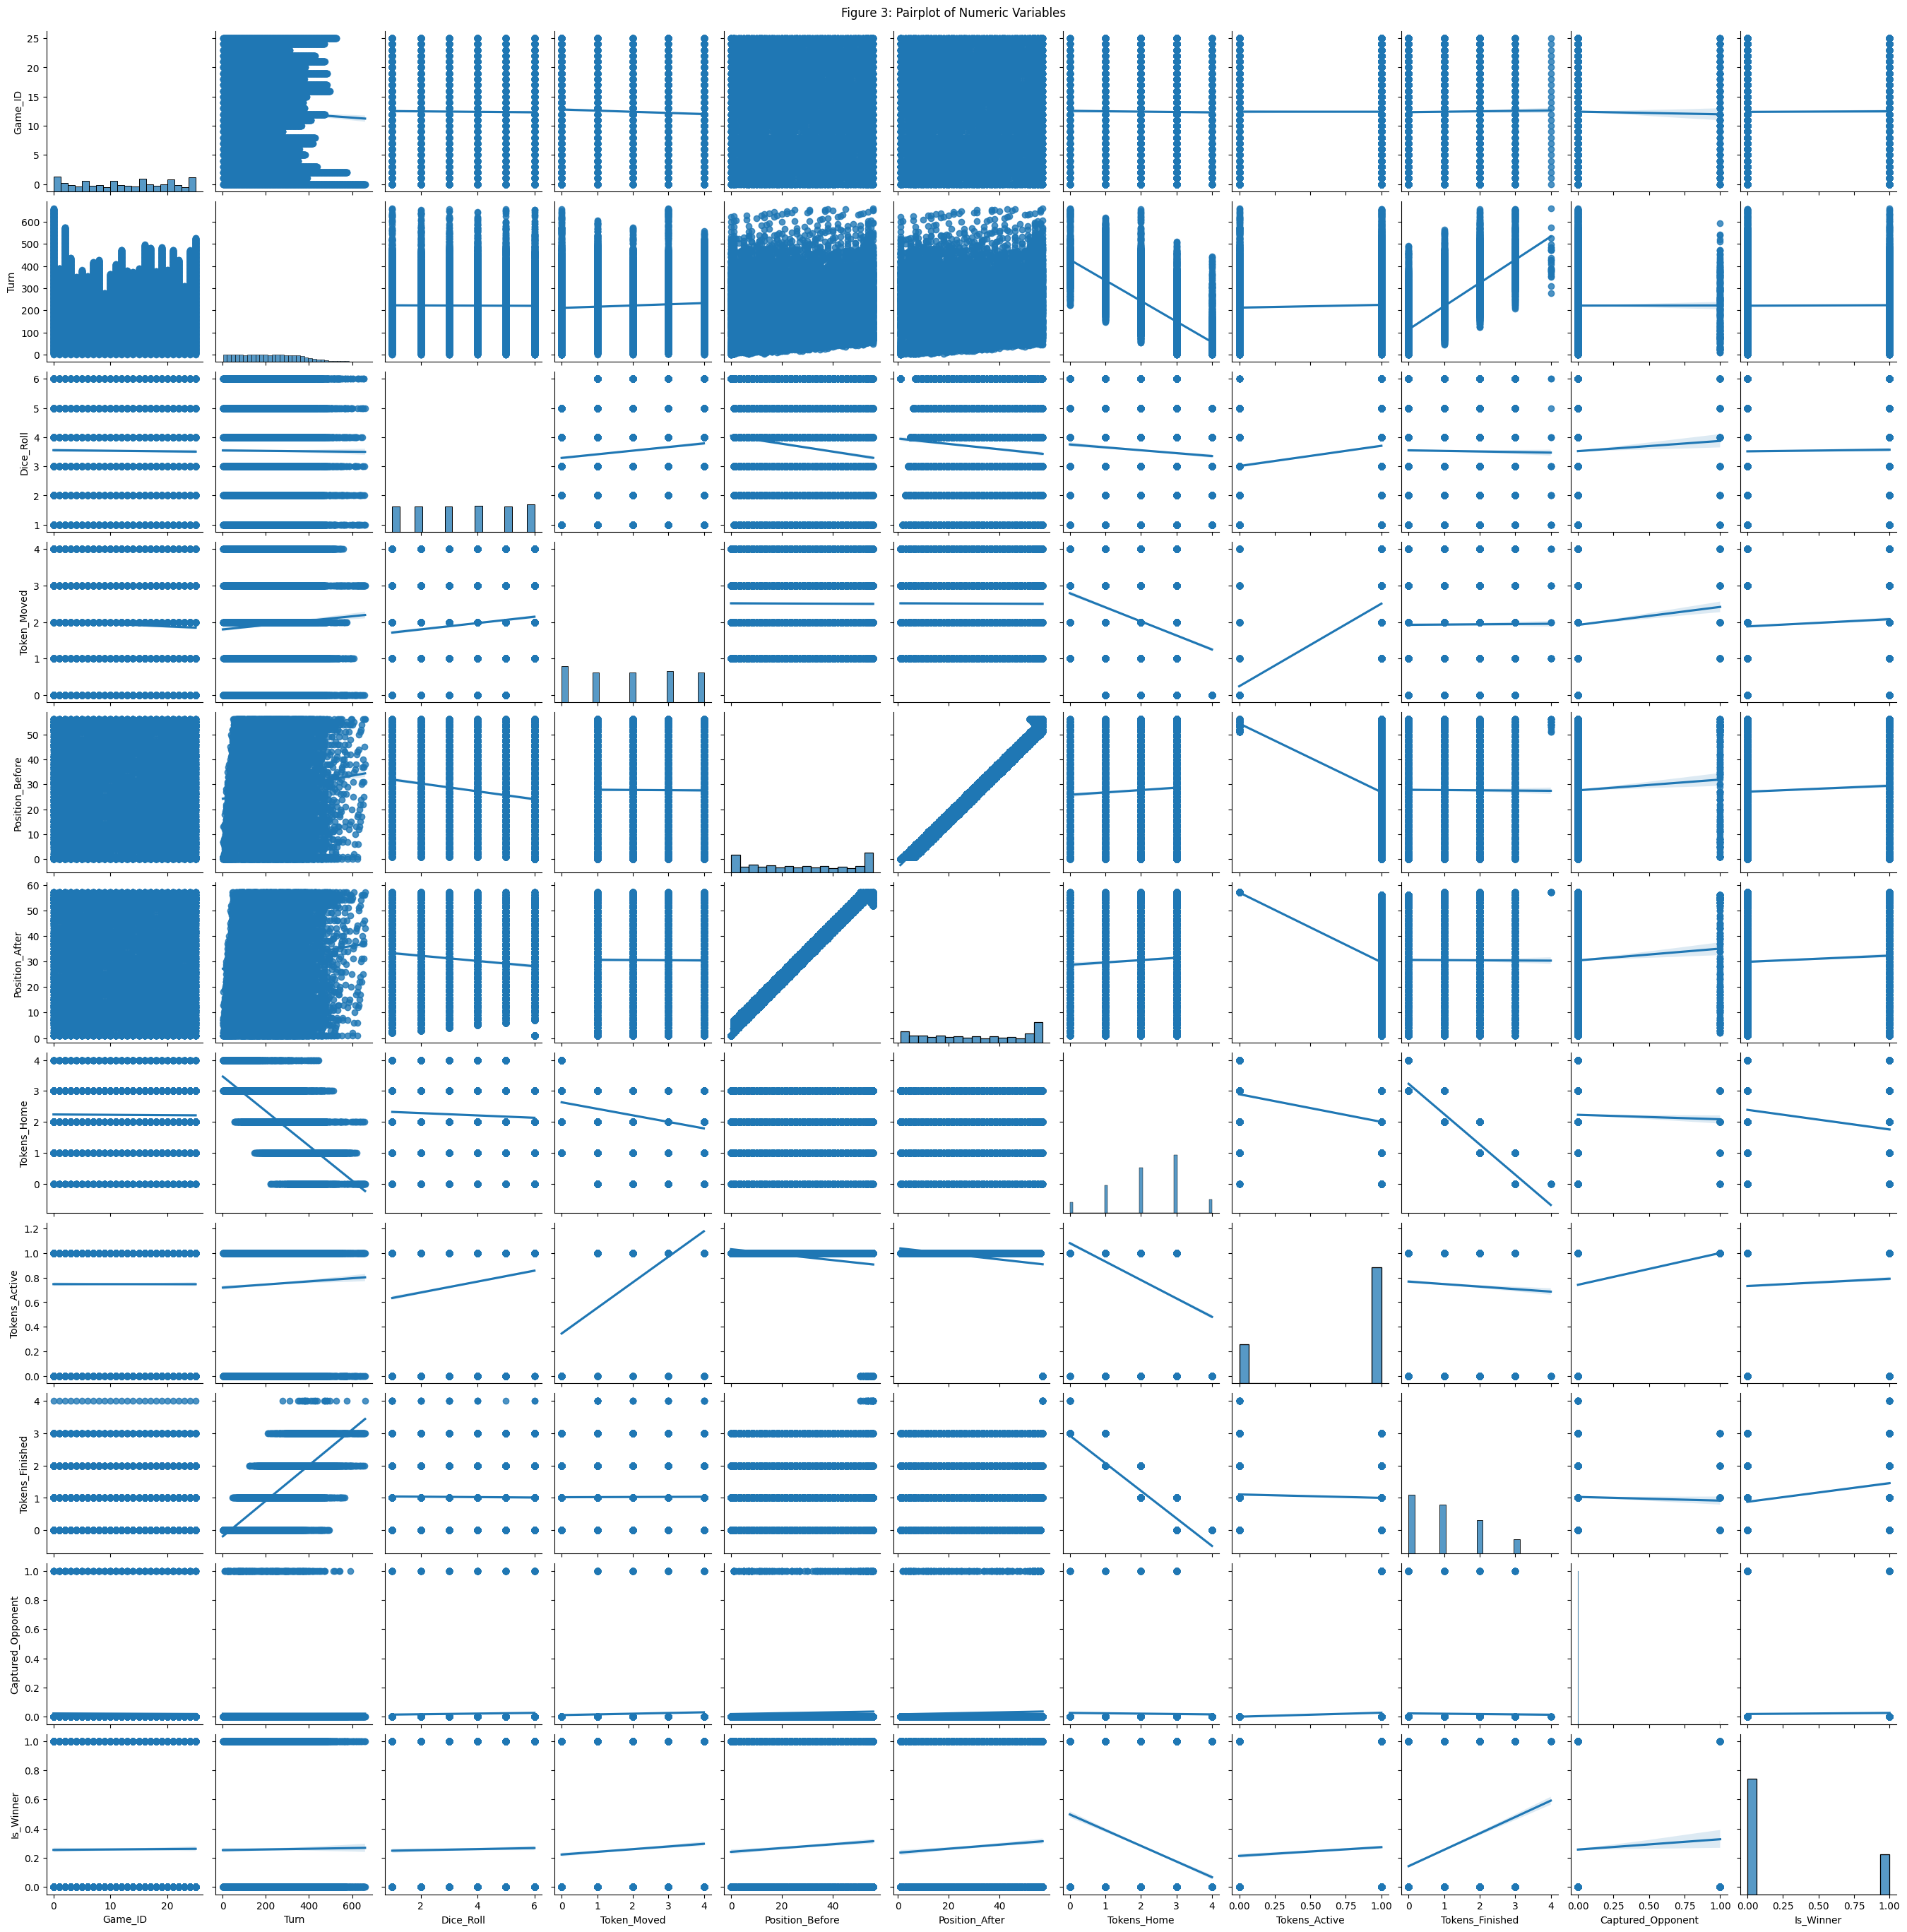

In [8]:
# Visualization of the relationships between numeric variables using pairplot with a regression line
sns.pairplot(df_num, kind='reg')
plt.suptitle('Figure 3: Pairplot of Numeric Variables', y=1)
plt.show()

## Step 4c — Categorical Variable Distribution: Countplot

### Why this step?
Countplots display the frequency of each level in categorical columns, providing a quick visual check of:
- **Class balance** — equal representation of players and other categorical groups prevents systematic bias in grouped analyses and machine learning models.
- **Unexpected categories** — values outside the expected set (e.g., a `Player_5` in a 4-player game) immediately signal a data error.
- **Dominant categories** — heavily imbalanced classes may need stratified sampling or class weighting for modelling.

### Expected variables & levels
| Variable | Expected levels | Expected distribution |
|---|---|---|
| `Player` | `Player_1`, `Player_2`, `Player_3`, `Player_4` | Approximately equal — each player takes roughly the same number of turns across many games |

### Interpretation guide
- **Balanced bars**: all players have similar turn counts, confirming the simulation is unbiased with respect to player assignment.
- **Mildly imbalanced bars**: players who roll a 6 or capture opponents more frequently receive extra turns — a genuine game mechanic, not a data error.
- **Severely imbalanced bars**: one player has far more or fewer turns than others — investigate whether player elimination (all tokens captured) is reducing their turn count.
- **Missing levels**: if any expected player label is absent, the simulation may not have correctly initialised all 4 players.

### Connection to subsequent steps
The player distribution observed here becomes the **grouping variable** in the Kruskal-Wallis test (Step 6c), where numeric variables are formally compared across player groups to identify statistically significant differences.

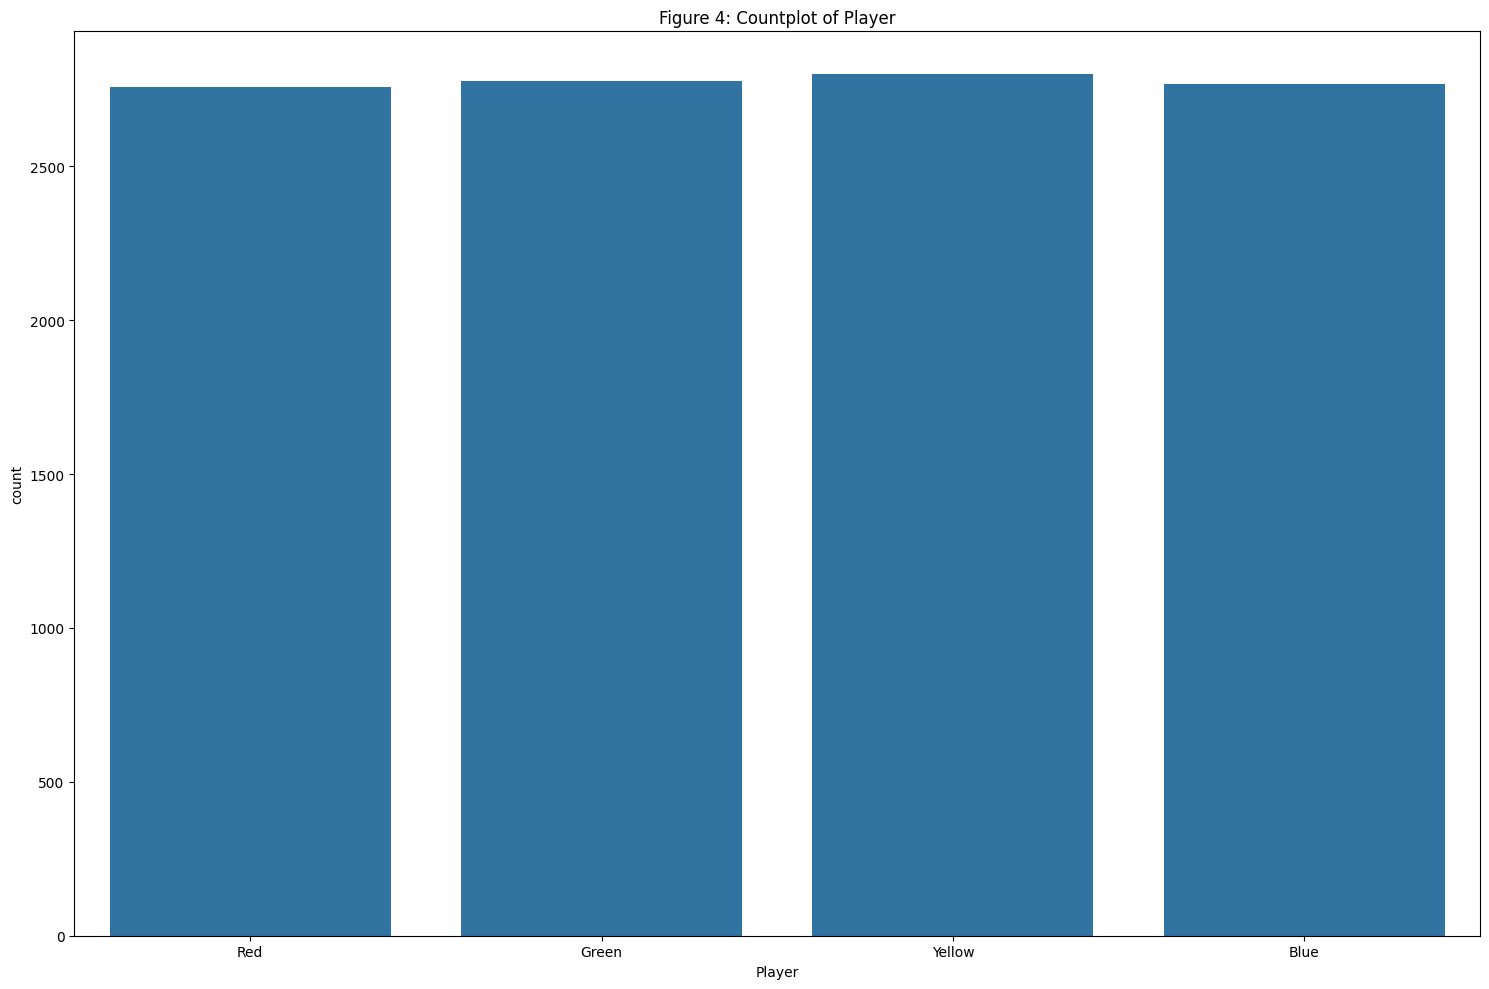

In [9]:
# Distribution of categorical variables using countplots removing unnecessary axes

df_cat=df.select_dtypes(include=['object'])
figure= plt.subplots(nrows=1, ncols=1, figsize=(15, 10))
for i, col in enumerate(df_cat.columns):
    sns.countplot(x=df_cat[col], ax=plt.gca())
    plt.title(f'Figure 4: Countplot of {col}')
plt.tight_layout()
plt.show()

## Step 4d — Numeric Variables Grouped by Categorical Variables

### Why this step?
Comparing numeric distributions across categorical groups is fundamental to understanding whether categorical variables (e.g., `Player`) systematically influence outcomes (e.g., `Dice_Roll`, `Tokens_Finished`, `Captured_Opponent`). This step provides a **visual pre-check** before formal statistical testing — it helps identify which variables are worth testing and builds intuition for interpreting test results.

### How to read the grouped boxplots
- Each box represents the distribution of the numeric variable for one category level.
- **Boxes at similar heights with overlapping IQRs**: no obvious group difference — the formal test will likely be non-significant.
- **Boxes at different heights or with separated IQRs**: possible group difference — the Kruskal-Wallis test (Step 6c) will quantify this.
- **Box widths and whisker lengths**: indicate spread and variability within each group.

### Key comparisons to examine
| Numeric variable | Grouped by `Player` | What to look for |
|---|---|---|
| `Dice_Roll` | Player | Should be nearly identical across all players — dice are fair and independent of player |
| `Tokens_Finished` | Player | Minor differences expected due to game dynamics; large differences may indicate turn-order bias |
| `Captured_Opponent` | Player | Players in certain board positions may capture more often due to game geometry and token density |
| `Turn` | Player | Players who win early have fewer total turns; this varies per game rather than per player |
| `Is_Winner` | Player | Should be roughly equal if the simulation is symmetric and unbiased |

### Connection to statistical testing
Visual differences spotted here are explored further and formally confirmed (or rejected) by the Kruskal-Wallis tests in Step 6c. These plots are **exploratory and visual**; the tests in Step 6c are **inferential and quantified**. Never conclude significance from a visual alone — use the plots to guide attention and the tests to establish evidence.

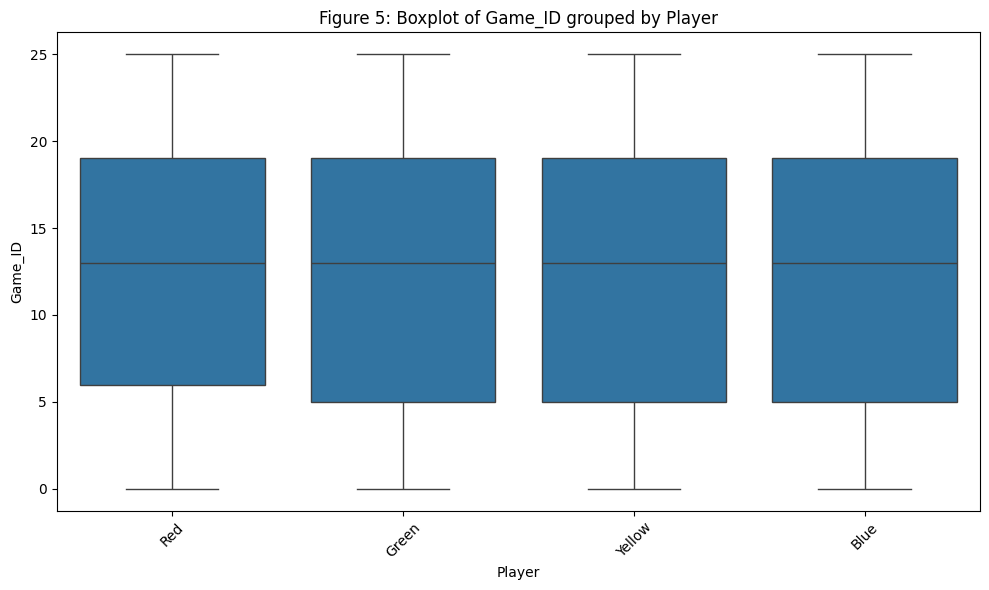

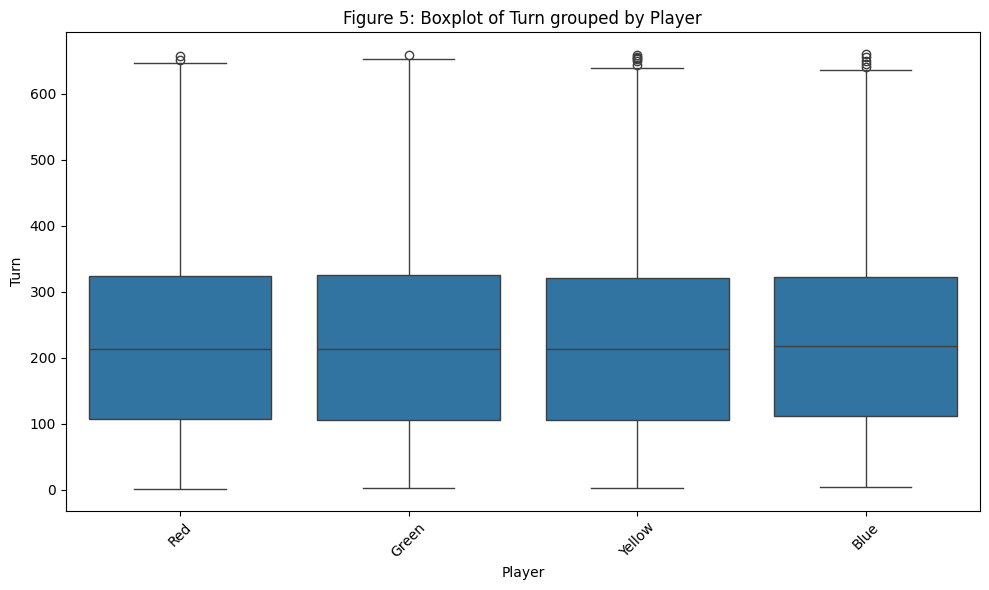

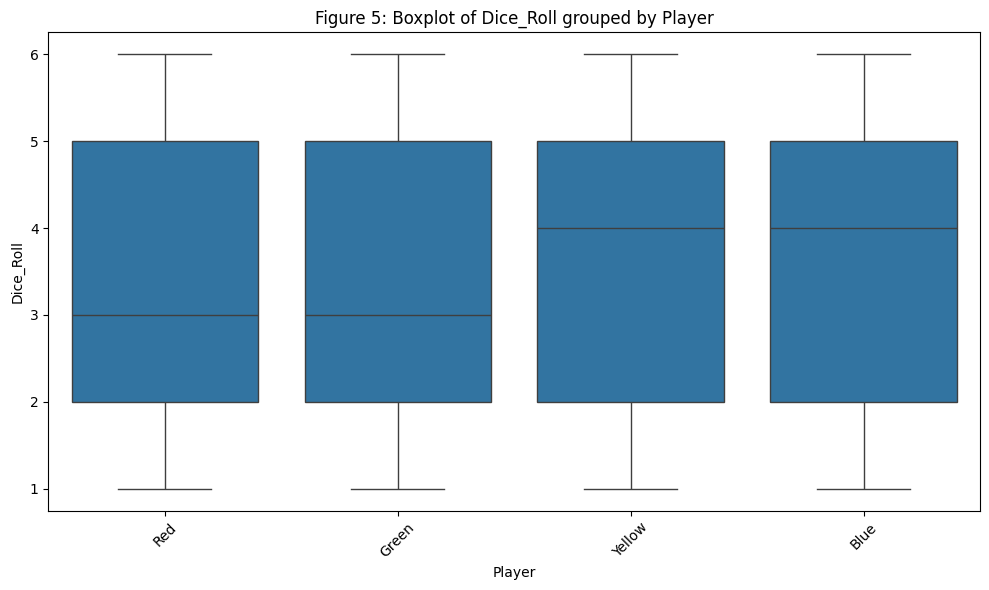

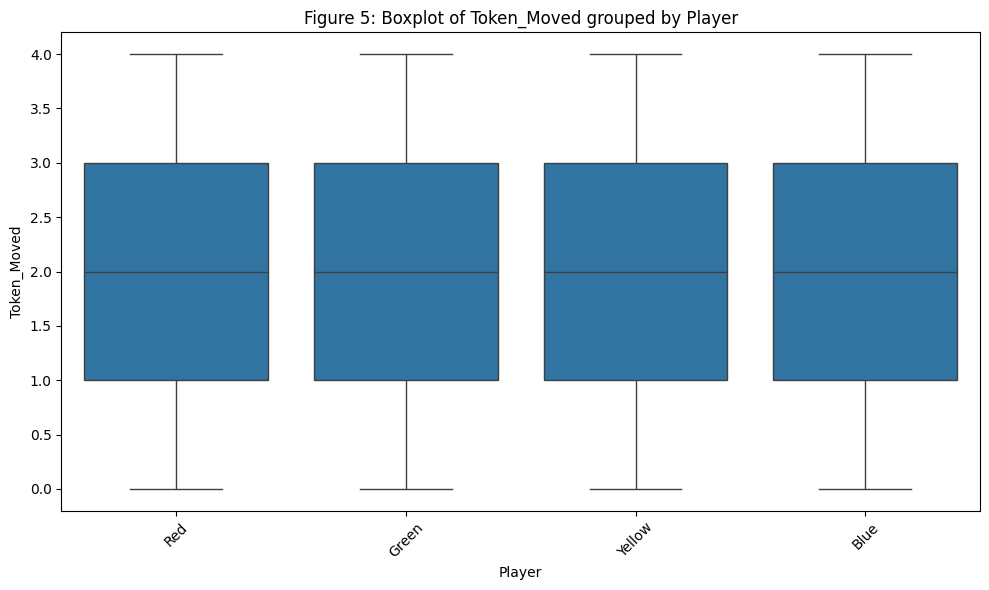

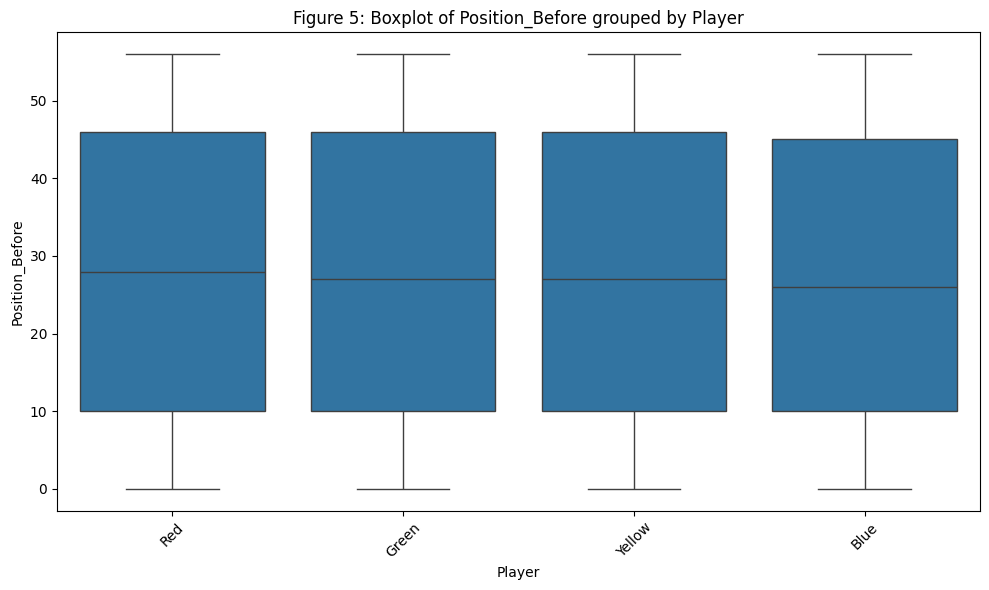

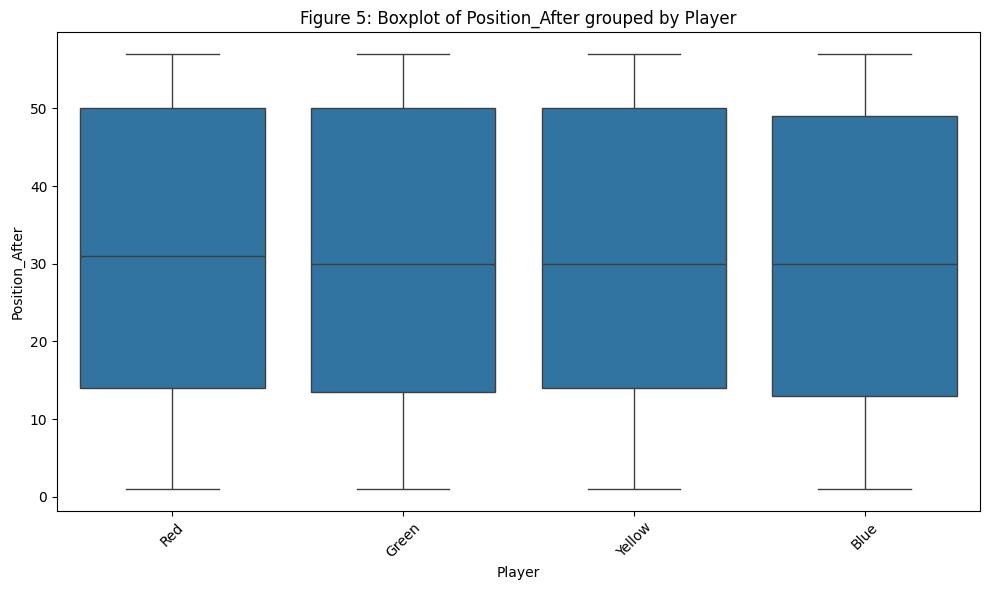

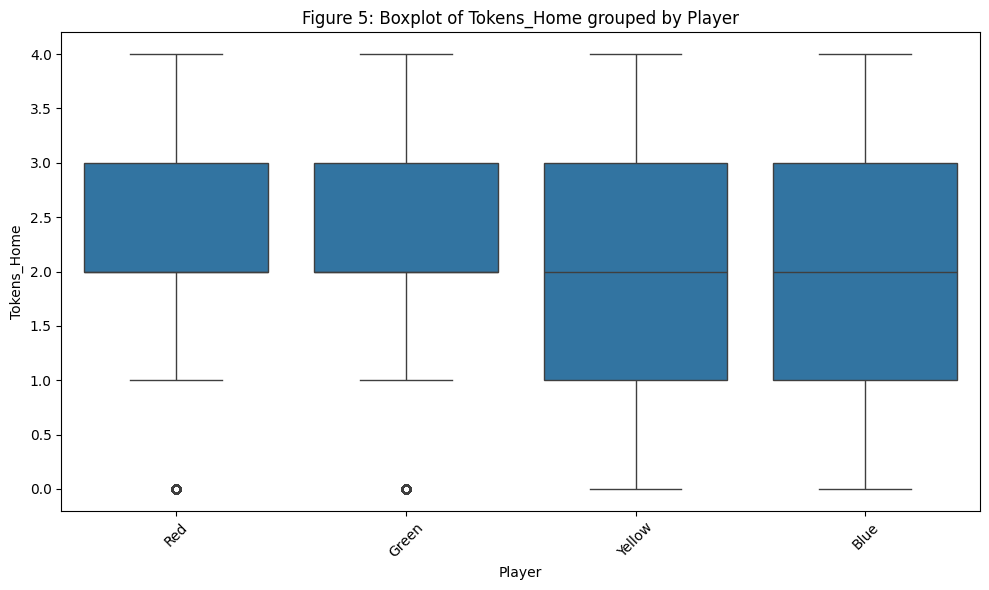

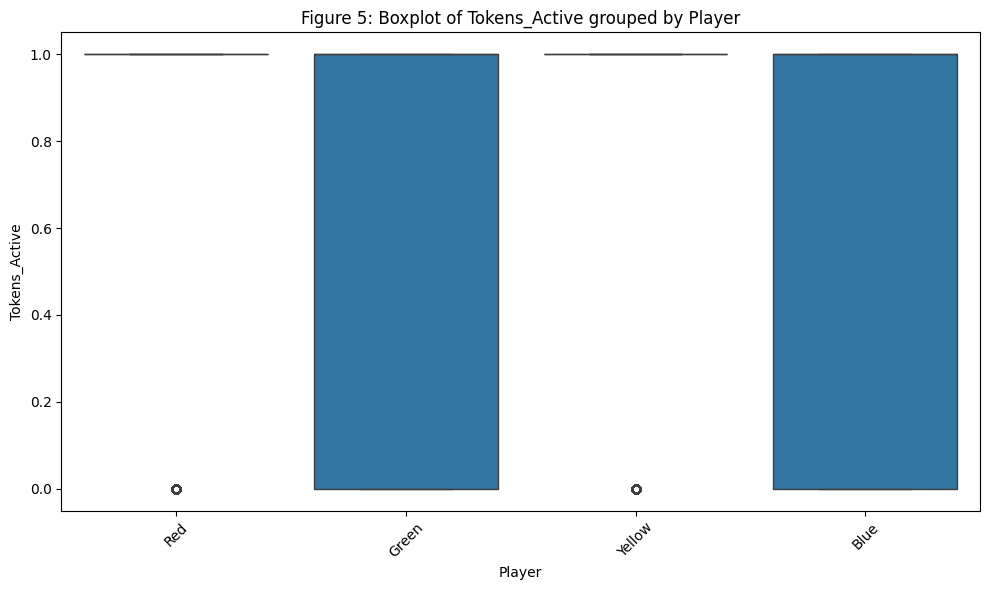

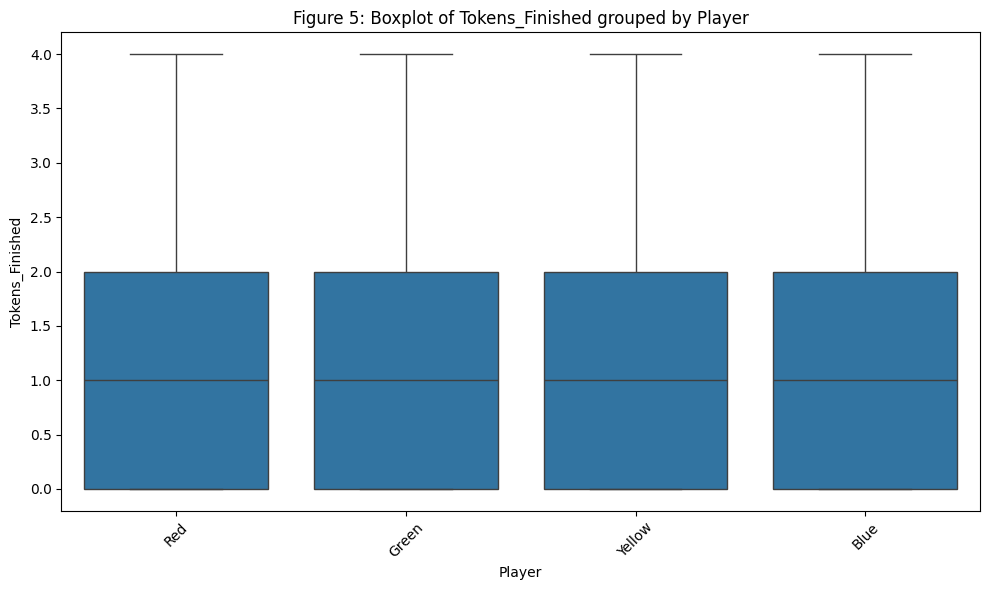

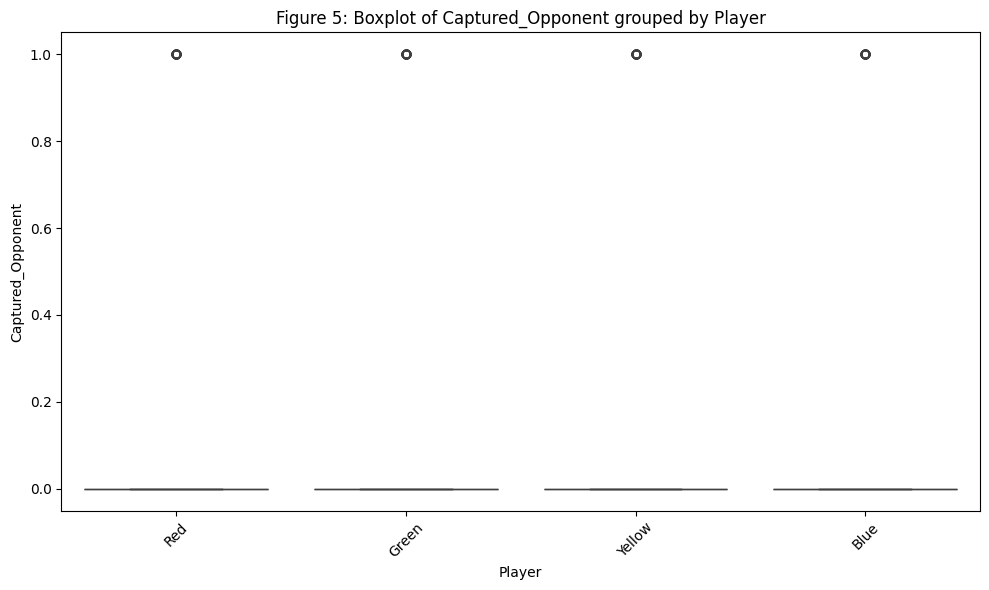

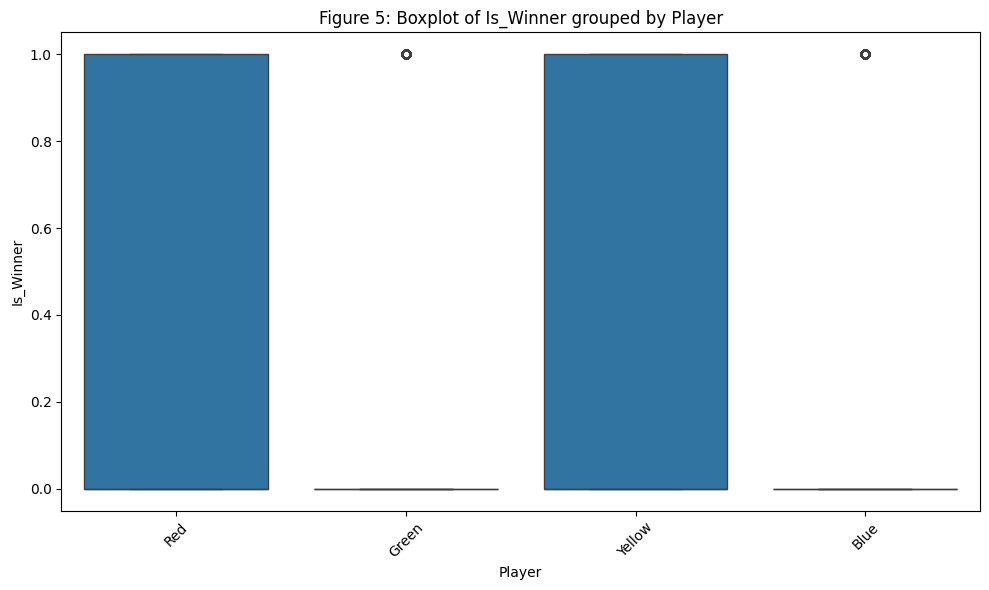

In [10]:
 # Distribution of the numeric variables when grouped by the categorical variables using boxplots
for cat_col in df_cat.columns:
    for num_col in df_num.columns:
        plt.figure(figsize=(10, 6))
        sns.boxplot(x=df[cat_col], y=df[num_col])
        plt.title(f'Figure 5: Boxplot of {num_col} grouped by {cat_col}')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

---
# Statistical Tests

The EDA phase (Steps 1–5) established the data structure, quality, and distribution patterns of all variables. The statistical testing phase now formalises these observations with hypothesis-driven inference.

## Testing strategy
Because most variables are discrete, bounded, and non-normally distributed (as confirmed in Steps 6a–6b), **non-parametric tests** are used for group comparisons:

| Test | Applied in | Null hypothesis |
|---|---|---|
| Shapiro-Wilk / D'Agostino-Pearson | Steps 6a & 6b | Variable is normally distributed (globally or within a group) |
| Kruskal-Wallis | Step 6c | All 4 player-group distributions are equal for the numeric variable |
| Mann-Whitney U | Step 6d | Both winner-status group distributions are equal for the numeric variable |

## Significance level
All tests use $\alpha = 0.05$. A $p$-value below this threshold leads to **rejection of $H_0$** (statistically significant result).

## Concentration overlays on significant plots
A statistically significant $p$-value answers **whether** groups differ, but not **how** or **where** they differ. The concentration overlays added to significant plots answer the practical question:

| Overlay | Meaning |
|---|---|
| **IQR band ($Q1$–$Q3$)** | Middle 50% concentration zone — narrower bands indicate tighter group concentration |
| **Median line ($Q2$)** | Robust central tendency — compare across groups to identify which has higher/lower typical values |
| **Peak marker (≈ mode)** | Highest-density bin midpoint — identifies where values cluster most strongly within the group |

## Step 5 — Correlation Analysis: Spearman Heatmap

### Why Spearman and not Pearson?
**Pearson correlation** measures linear relationships and assumes both variables are normally distributed and continuous. Given the non-normal, discrete, and bounded nature of variables in this dataset, **Spearman rank correlation** is more appropriate: it measures **monotonic** relationships without normality requirements and is robust to outliers and ties.

### How to read the heatmap
| $\rho$ range | Interpretation |
|---|---|
| +0.7 to +1.0 | Strong positive monotonic relationship |
| +0.3 to +0.7 | Moderate positive monotonic relationship |
| −0.3 to +0.3 | Weak or no monotonic relationship |
| −0.7 to −0.3 | Moderate negative monotonic relationship |
| −1.0 to −0.7 | Strong negative monotonic relationship |

- **Colour**: Red = positive correlation; Blue = negative correlation; White/light = near zero.
- **Annotated values**: exact Spearman $\rho$ rounded to 2 decimal places.
- **Diagonal**: always 1.0 (self-correlation); ignore for interpretation.

### Expected relationships
| Variable pair | Expected $\rho$ | Reason |
|---|---|---|
| `Tokens_Home` ↔ `Tokens_Active` | Negative | As tokens leave home, active count rises |
| `Tokens_Active` ↔ `Tokens_Finished` | Negative | As tokens finish, active count falls |
| `Tokens_Finished` ↔ `Is_Winner` | Positive | Winners accumulate more finished tokens |
| `Position_Before` ↔ `Position_After` | Strong positive | Position changes by at most one roll per turn |
| `Dice_Roll` ↔ other variables | Near zero | Dice rolls are independent of game state |

### Implications for feature engineering
- **Highly correlated pairs** ($|\rho| > 0.8$) may be redundant — one feature could be dropped to reduce dimensionality without significant information loss.
- **Features with strong correlation to `Is_Winner`** are primary candidates for the predictive model.
- This heatmap complements the normality and group-comparison steps: variables that correlate strongly with `Is_Winner` and show significant Mann-Whitney U results (Step 6d) are the highest-priority features.

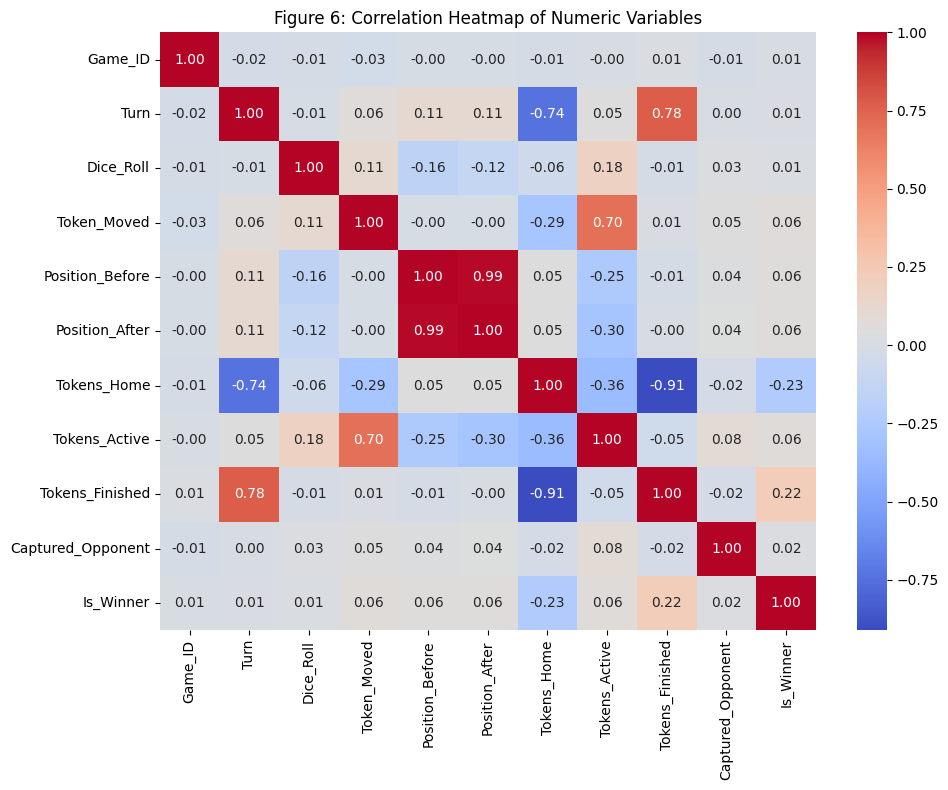

In [11]:
# Correlation heatmap of numeric variables
plt.figure(figsize=(10, 8))
correlation_matrix = df_num.corr(method='spearman')
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Figure 6: Correlation Heatmap of Numeric Variables')
plt.tight_layout()
plt.show()

## Step 6a — Global Normality Testing

### Why this step?
The choice between parametric tests (t-test, ANOVA) and non-parametric alternatives (Mann-Whitney U, Kruskal-Wallis) depends on whether the data satisfies normality assumptions. This cell formally tests each numeric variable across the full dataset, providing an evidence-based justification for the test strategy used in Steps 6c and 6d.

### Test selection logic
| Sample size | Test used | Reason |
|---|---|---|
| n ≤ 5,000 | **Shapiro-Wilk** | The most powerful normality test for small-to-medium samples; sensitive to even minor departures from normality |
| n > 5,000 | **D'Agostino-Pearson** (`normaltest`) | Shapiro-Wilk becomes unreliable for very large samples; `normaltest` combines skewness and kurtosis statistics and maintains good power at scale |

### Hypotheses
$$H_0: \text{The variable is normally distributed}$$
$$H_1: \text{The variable is not normally distributed}$$

### Output table columns
| Column | Meaning |
|---|---|
| `variable` | Name of the numeric column tested |
| `n` | Sample size after dropping `NaN`s |
| `test_used` | `shapiro` or `normaltest` |
| `null_hypothesis` | Stated $H_0$ for reference |
| `statistic` | W (Shapiro-Wilk) or $k^2$ (D'Agostino-Pearson) |
| `p_value` | Probability of observing this statistic under $H_0$ |
| `normal` | `True` if $p > \alpha$ (fail to reject $H_0$) |
| `decision` | `Accept H0` (normal) or `Reject H0` (non-normal) |
| `indication` | Plain-language summary of the result |

### Expected result
Most Ludo variables are discrete, bounded, or heavily skewed — `Captured_Opponent` (mostly 0), `Token_Moved` (discrete 0–4), `Dice_Roll` (uniform 1–6), `Tokens_Finished` (early-game spike at 0) — so the majority are expected to **reject $H_0$**, confirming non-normality and directly justifying the non-parametric tests applied in Steps 6c and 6d.

In [12]:
# Tests for normality of numeric variables with automatic method switch from shapiro to normaltest(n > 5000), alpha=0.05
normality_rows = []
alpha = 0.05

for col in df_num.columns:
    series = df_num[col].dropna()
    method = 'normaltest' if len(series) > 5000 else 'shapiro'
    result = pg.normality(series, method=method, alpha=alpha)

    p_value = result['pval'].iloc[0]
    is_normal = bool(result['normal'].iloc[0])
    decision = 'Accept H0' if is_normal else 'Reject H0'
    normality_rows.append({
        'variable': col,
        'n': len(series),
        'test_used': method,
        'null_hypothesis': 'Variable is normally distributed',
        'statistic': result.iloc[0, 0],
        'p_value': p_value,
        'normal': is_normal,
        'decision': decision,
        'indication': 'Normally distributed' if is_normal else 'Not normally distributed',
    })

normality_df = pd.DataFrame(normality_rows)
normality_df

,variable,n,test_used,null_hypothesis,statistic,p_value,normal,decision,indication
0,Game_ID,11104,normaltest,Variable is normally distributed,1.608647e+04,0.000000e+00,False,Reject H0,Not normally distributed
1,Turn,11104,normaltest,Variable is normally distributed,4.782521e+02,1.408913e-104,False,Reject H0,Not normally distributed
2,Dice_Roll,11104,normaltest,Variable is normally distributed,2.574217e+04,0.000000e+00,False,Reject H0,Not normally distributed
3,Token_Moved,11104,normaltest,Variable is normally distributed,2.781027e+06,0.000000e+00,False,Reject H0,Not normally distributed
4,Position_Before,8556,normaltest,Variable is normally distributed,8.695451e+04,0.000000e+00,False,Reject H0,Not normally distributed
5,Position_After,8556,normaltest,Variable is normally distributed,9.152747e+04,0.000000e+00,False,Reject H0,Not normally distributed
6,Tokens_Home,11104,normaltest,Variable is normally distributed,5.223001e+02,3.836833e-114,False,Reject H0,Not normally distributed
7,Tokens_Active,11104,normaltest,Variable is normally distributed,2.198863e+03,0.000000e+00,False,Reject H0,Not normally distributed
8,Tokens_Finished,11104,normaltest,Variable is normally distributed,1.179321e+03,8.197611e-257,False,Reject H0,Not normally distributed
9,Captured_Opponent,11104,normaltest,Variable is normally distributed,1.337192e+04,0.000000e+00,False,Reject H0,Not normally distributed


## Step 6b — Grouped Normality Testing

### Why this step?
Even if a variable is non-normal globally, individual subgroups could potentially satisfy normality. For example, `Player_1`'s `Dice_Roll` distribution might pass a normality test even if the full dataset does not. This matters for deciding whether group-comparison tests should be parametric (ANOVA) or non-parametric (Kruskal-Wallis).

This cell tests normality for every `(categorical variable, category level, numeric variable)` triple, providing a comprehensive per-group normality profile.

### Test selection logic
The same automatic switching rule as Step 6a applies:
- **n > 5,000** → D'Agostino-Pearson (`normaltest`)
- **n ≤ 5,000** → Shapiro-Wilk (`shapiro`)
- **n < 3** → Skipped (insufficient data; marked as non-normal and `Reject H0` by default)

### Hypotheses (per group)
$$H_0: \text{The numeric variable is normally distributed within this group}$$
$$H_1: \text{The numeric variable is not normally distributed within this group}$$

### Output table columns
| Column | Meaning |
|---|---|
| `categorical_variable` | Grouping column (e.g., `Player`) |
| `category` | Specific group level (e.g., `Player_1`) |
| `numeric_variable` | Column being tested |
| `n` | Sample size for this group after dropping `NaN`s |
| `test_used` | `shapiro`, `normaltest`, or `None` (n < 3) |
| `null_hypothesis` | Stated $H_0$ for reference |
| `statistic` | Test statistic |
| `p_value` | $p$-value under $H_0$ |
| `normal` | `True` if $p > \alpha$ |
| `decision` | `Accept H0` / `Reject H0` |
| `indication` | Plain-language summary |

### Decision rule for subsequent tests
| Normality result | Recommended test |
|---|---|
| All groups of a variable are normal | Parametric one-way ANOVA (rarely applies here) |
| Any group of a variable is non-normal | Non-parametric Kruskal-Wallis (applied in Step 6c) |

The results from this table directly and formally justify the non-parametric approach taken in Steps 6c and 6d.

In [13]:
# Tests for normality of numeric variables within each category level, alpha=0.05
grouped_normality_rows = []
alpha = 0.05

for cat_col in df_cat.columns:
    for num_col in df_num.columns:
        subset = df[[cat_col, num_col]].dropna()
        for group_name, group_df in subset.groupby(cat_col):
            series = group_df[num_col]
            n = len(series)

            if n < 3:
                grouped_normality_rows.append({
                    'categorical_variable': cat_col,
                    'category': group_name,
                    'numeric_variable': num_col,
                    'n': n,
                    'test_used': None,
                    'null_hypothesis': 'Group variable is normally distributed',
                    'statistic': np.nan,
                    'p_value': np.nan,
                    'normal': False,
                    'decision': 'Reject H0',
                    'indication': 'Insufficient sample size (n < 3)'
                })
                continue

            method = 'normaltest' if n > 5000 else 'shapiro'
            result = pg.normality(series, method=method, alpha=alpha)

            p_value = result['pval'].iloc[0]
            is_normal = bool(result['normal'].iloc[0])
            decision = 'Accept H0' if is_normal else 'Reject H0'

            grouped_normality_rows.append({
                'categorical_variable': cat_col,
                'category': group_name,
                'numeric_variable': num_col,
                'n': n,
                'test_used': method,
                'null_hypothesis': 'Group variable is normally distributed',
                'statistic': result.iloc[0, 0],
                'p_value': p_value,
                'normal': is_normal,
                'decision': decision,
                'indication': 'Normally distributed' if is_normal else 'Not normally distributed'
            })

grouped_normality_df = pd.DataFrame(grouped_normality_rows)
grouped_normality_df

,categorical_variable,category,numeric_variable,n,test_used,null_hypothesis,statistic,p_value,normal,decision,indication
0,Player,Blue,Game_ID,2769,shapiro,Group variable is normally distributed,0.942993,1.977329e-31,False,Reject H0,Not normally distributed
1,Player,Green,Game_ID,2779,shapiro,Group variable is normally distributed,0.943801,2.705917e-31,False,Reject H0,Not normally distributed
2,Player,Red,Game_ID,2757,shapiro,Group variable is normally distributed,0.945084,6.946862e-31,False,Reject H0,Not normally distributed
3,Player,Yellow,Game_ID,2799,shapiro,Group variable is normally distributed,0.943772,2.120738e-31,False,Reject H0,Not normally distributed
4,Player,Blue,Turn,2769,shapiro,Group variable is normally distributed,0.973270,2.353142e-22,False,Reject H0,Not normally distributed
5,Player,Green,Turn,2779,shapiro,Group variable is normally distributed,0.971637,4.773249e-23,False,Reject H0,Not normally distributed
6,Player,Red,Turn,2757,shapiro,Group variable is normally distributed,0.972785,1.676532e-22,False,Reject H0,Not normally distributed
7,Player,Yellow,Turn,2799,shapiro,Group variable is normally distributed,0.971326,2.984090e-23,False,Reject H0,Not normally distributed
8,Player,Blue,Dice_Roll,2769,shapiro,Group variable is normally distributed,0.904383,1.438212e-38,False,Reject H0,Not normally distributed
9,Player,Green,Dice_Roll,2779,shapiro,Group variable is normally distributed,0.903713,9.990663e-39,False,Reject H0,Not normally distributed


## Transition: From Normality Testing to Non-Parametric Group Comparisons

The normality tests in Steps 6a and 6b almost universally rejected $H_0$ across both global and group-level tests. This is expected given the nature of Ludo dataset variables:

- **Discrete and bounded**: `Dice_Roll` ∈ {1–6}, `Token_Moved` ∈ {0–4}, `Captured_Opponent` and `Is_Winner` are binary (0/1).
- **Skewed**: `Captured_Opponent` has most values at 0 (captures are rare); `Tokens_Finished` spikes at 0 early in games.
- **Multimodal**: `Position_Before` and `Position_After` spike at 0 (home yard) and at 57 (finish zone).

Since most variables and groups do not satisfy normality assumptions, the non-parametric tests applied next are the appropriate choice:

| Comparison | Test | Why chosen |
|---|---|---|
| 4 player groups | **Kruskal-Wallis** | Non-parametric extension of one-way ANOVA; ranks all observations and compares mean ranks across groups without assuming normality |
| 2 winner-status groups (`Is_Winner` 0 vs 1) | **Mann-Whitney U** | Non-parametric equivalent of the independent-samples t-test; counts how often a value from one group exceeds a value from the other |

### How to read the concentration overlays on significant plots
A significant $p$-value tells you **whether** groups differ statistically. The concentration overlays tell you **how** and **where** they differ in practical terms:

| Overlay | Definition | How to use it |
|---|---|---|
| **IQR band ($Q1$ to $Q3$)** | Middle 50% of values for the group | Narrower band = tighter concentration; wider band = higher spread. Overlapping IQR bands between groups suggest practical similarity despite statistical significance |
| **Median line ($Q2$)** | 50th percentile of the group | Robust central tendency; compare medians across groups to determine which has higher or lower typical values |
| **Peak marker (≈ mode)** | Midpoint of the highest-density histogram bin | Most common value range for the group; where observations cluster most densely |

Together, $p$-values establish **statistical significance**; overlays establish **practical significance and distribution shape**.

## Step 6c — Kruskal-Wallis Test: Numeric Variables Across Player Groups

### Why this step?
The Kruskal-Wallis test determines whether at least one player group has a statistically different distribution for a given numeric variable. Finding group differences reveals that a player's position, turn order, or game dynamics systematically affect that variable — providing valuable signal for the downstream predictive model and flagging potential simulation biases.

### Hypotheses
$$H_0: \text{The distributions of } X \text{ are equal across all player groups}$$
$$H_1: \text{At least one player group has a different distribution of } X$$

### How the test works
1. All observations are pooled and ranked from smallest (rank 1) to largest.
2. The H statistic measures how much the mean rank of each group deviates from the overall mean rank.
3. Large H → group mean ranks are spread apart → likely different distributions → small $p$-value → reject $H_0$.

### Output — results table columns
| Column | Meaning |
|---|---|
| `grouping_variable` | `Player` |
| `numeric_variable` | Variable being tested |
| `groups_compared` | All player labels joined by ` vs ` |
| `null_hypothesis` | Stated $H_0$ |
| `alpha` | Significance level (0.05) |
| `H_value` | Kruskal-Wallis H statistic |
| `p_value` | $p$-value under $H_0$ |
| `significant` | `True` if $p < \alpha$ |
| `decision` | `Accept H0` / `Reject H0` |

### Output — visualisations (significant variables only)
For each variable where $H_0$ is rejected, a **swarmplot overlaid on a boxplot** is generated with concentration overlays:
- **Swarmplot**: plots every individual observation as a dot, revealing the full distribution shape without overplotting.
- **Boxplot (background, light grey)**: shows IQR, median, and whisker range as context.
- **Crimson IQR band**: shaded region covering Q1–Q3 for each player, indicating middle-50% concentration.
- **Dashed crimson median line**: per-player median, enabling direct cross-group comparison.
- **Dark red diamond marker**: approximate peak (mode region) per player.

### Output — concentration summary table
A `DataFrame` with columns `Numeric_Variable`, `Player`, `Q1`, `Median`, `Q3`, `Peak_Approx` is displayed below each significant plot, providing exact numeric values for all concentration overlays.

### Game-context interpretation guide
| Significant variable | Possible explanation |
|---|---|
| `Dice_Roll` | Unexpected — dice should be fair across all players. If significant, investigate simulation randomness |
| `Tokens_Finished` | Plausible — first-mover advantage or last-player disadvantage due to turn order across many games |
| `Captured_Opponent` | Plausible — certain starting positions on the board create more frequent collision and capture opportunities |
| `Turn` | Reflects winner/loser dynamics more than player identity; winners finish faster |

,grouping_variable,numeric_variable,groups_compared,null_hypothesis,alpha,statistic,p_value,significant,decision
0,Player,Turn,Blue vs Green vs Red vs Yellow,All player-group distributions are equal,0.05,0.489066,9.212870e-01,False,Accept H0
1,Player,Dice_Roll,Blue vs Green vs Red vs Yellow,All player-group distributions are equal,0.05,5.847954,1.192465e-01,False,Accept H0
2,Player,Token_Moved,Blue vs Green vs Red vs Yellow,All player-group distributions are equal,0.05,44.153432,1.400065e-09,True,Reject H0
3,Player,Position_Before,Blue vs Green vs Red vs Yellow,All player-group distributions are equal,0.05,1.829951,6.084390e-01,False,Accept H0
4,Player,Position_After,Blue vs Green vs Red vs Yellow,All player-group distributions are equal,0.05,1.337719,7.201965e-01,False,Accept H0
5,Player,Tokens_Home,Blue vs Green vs Red vs Yellow,All player-group distributions are equal,0.05,34.951153,1.247544e-07,True,Reject H0
6,Player,Tokens_Active,Blue vs Green vs Red vs Yellow,All player-group distributions are equal,0.05,2.289427,5.145495e-01,False,Accept H0
7,Player,Tokens_Finished,Blue vs Green vs Red vs Yellow,All player-group distributions are equal,0.05,39.570947,1.313689e-08,True,Reject H0
8,Player,Captured_Opponent,Blue vs Green vs Red vs Yellow,All player-group distributions are equal,0.05,0.653819,8.840086e-01,False,Accept H0
9,Player,Is_Winner,Blue vs Green vs Red vs Yellow,All player-group distributions are equal,0.05,499.091672,7.507897e-108,True,Reject H0


/home/chizoalban2003/ludomaniac/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 33.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/chizoalban2003/ludomaniac/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 34.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/chizoalban2003/ludomaniac/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 28.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/chizoalban2003/ludomaniac/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 40.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ch

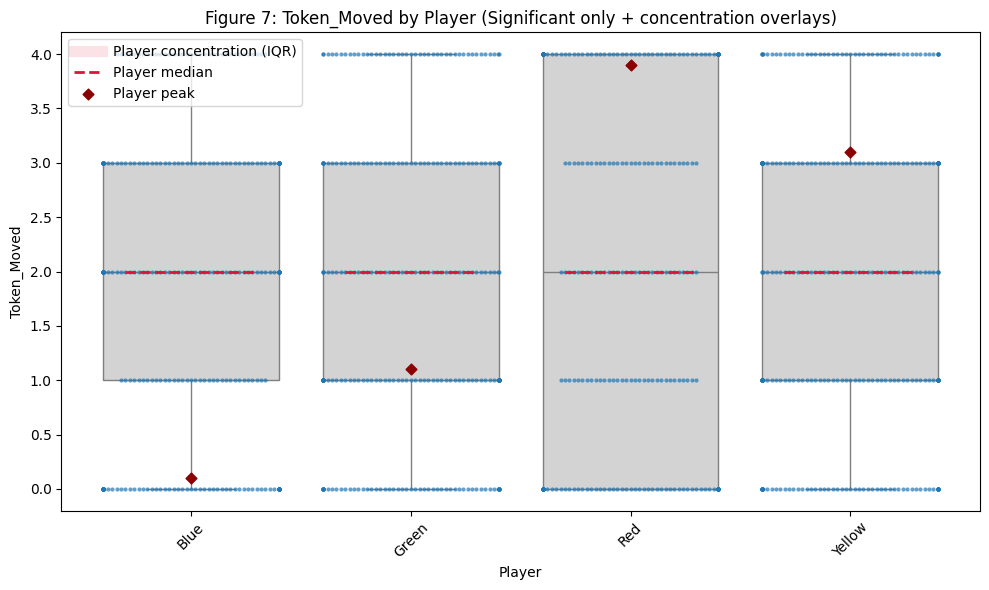

,Numeric_Variable,Player,Q1,Median,Q3,Peak_Approx
0,Token_Moved,Blue,1.0,2.0,3.0,0.1
1,Token_Moved,Green,1.0,2.0,3.0,1.1
2,Token_Moved,Red,0.0,2.0,4.0,3.9
3,Token_Moved,Yellow,1.0,2.0,3.0,3.1


/home/chizoalban2003/ludomaniac/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 46.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/chizoalban2003/ludomaniac/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 46.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/chizoalban2003/ludomaniac/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 39.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/chizoalban2003/ludomaniac/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 48.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ch

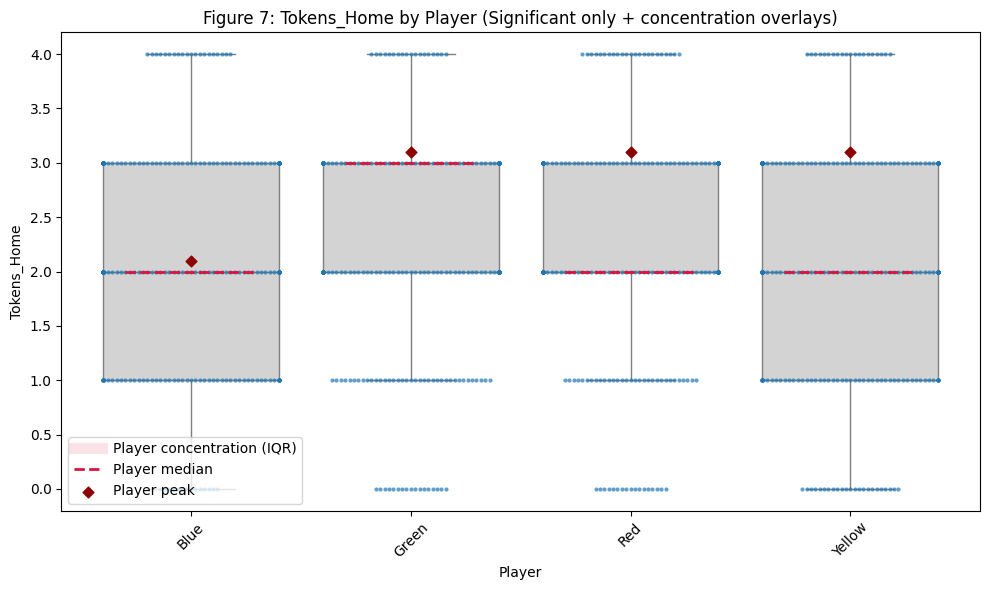

,Numeric_Variable,Player,Q1,Median,Q3,Peak_Approx
0,Tokens_Home,Blue,1.0,2.0,3.0,2.1
1,Tokens_Home,Green,2.0,3.0,3.0,3.1
2,Tokens_Home,Red,2.0,2.0,3.0,3.1
3,Tokens_Home,Yellow,1.0,2.0,3.0,3.1


/home/chizoalban2003/ludomaniac/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 51.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/chizoalban2003/ludomaniac/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 51.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/chizoalban2003/ludomaniac/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 46.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/chizoalban2003/ludomaniac/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 54.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ch

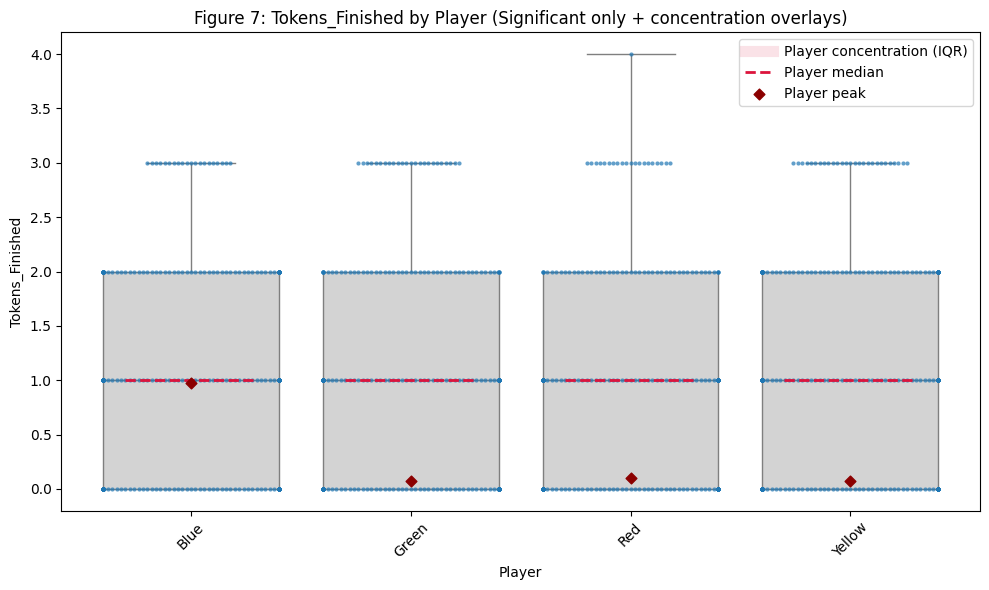

,Numeric_Variable,Player,Q1,Median,Q3,Peak_Approx
0,Tokens_Finished,Blue,0.0,1.0,2.0,0.98
1,Tokens_Finished,Green,0.0,1.0,2.0,0.08
2,Tokens_Finished,Red,0.0,1.0,2.0,0.10
3,Tokens_Finished,Yellow,0.0,1.0,2.0,0.08


/home/chizoalban2003/ludomaniac/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 73.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/chizoalban2003/ludomaniac/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 73.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/chizoalban2003/ludomaniac/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 70.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/chizoalban2003/ludomaniac/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 76.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ch

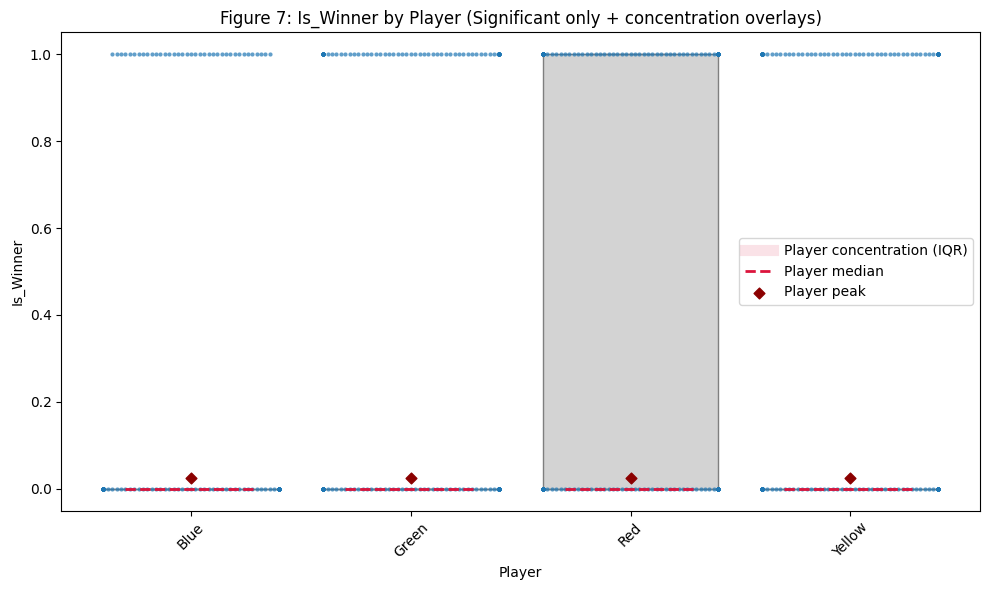

,Numeric_Variable,Player,Q1,Median,Q3,Peak_Approx
0,Is_Winner,Blue,0.0,0.0,0.0,0.02
1,Is_Winner,Green,0.0,0.0,0.0,0.02
2,Is_Winner,Red,0.0,0.0,1.0,0.02
3,Is_Winner,Yellow,0.0,0.0,0.0,0.02


In [ ]:
# Kruskal-Wallis tests for numeric variables across Player groups, alpha=0.05
alpha = 0.05
kruskal_rows = []

group_col = 'Player'
for num_col in df_num.columns:
    if num_col == 'Game_ID':
        continue

    subset = df[[group_col, num_col]].dropna()
    unique_groups = sorted(subset[group_col].unique())
    groups_compared = ' vs '.join(map(str, unique_groups))
    groups = [group[num_col].values for _, group in subset.groupby(group_col)]

    if len(groups) < 2 or any(len(group) == 0 for group in groups):
        kruskal_rows.append({
            'grouping_variable': group_col,
            'numeric_variable': num_col,
            'groups_compared': groups_compared,
            'null_hypothesis': 'All player-group distributions are equal',
            'alpha': alpha,
            'H_value': np.nan,
            'p_value': np.nan,
            'significant': False,
            'decision': 'Accept H0'
        })
        continue

    result = pg.kruskal(data=subset, dv=num_col, between=group_col)
    p_value = result['p_unc'].iloc[0]
    significant = bool(p_value < alpha)

    kruskal_rows.append({
        'grouping_variable': group_col,
        'numeric_variable': num_col,
        'groups_compared': groups_compared,
        'null_hypothesis': 'All player-group distributions are equal',
        'alpha': alpha,
        'H_value': result['H'].iloc[0],
        'p_value': p_value,
        'significant': significant,
        'decision': 'Reject H0' if significant else 'Accept H0'
    })

kruskal_df = pd.DataFrame(kruskal_rows)

# Always show the test result table when this cell runs
display(kruskal_df)

# Visualizations: boxplot + swarmplot only for variables with statistically significant differences
significant_vars = kruskal_df.loc[kruskal_df['significant'], 'numeric_variable'].tolist()

if not significant_vars:
    print('No statistically significant variables found at alpha=0.05; no swarmplots generated.')
else:
    for num_col in significant_vars:
        plot_df = df[[group_col, num_col]].dropna()
        if plot_df.empty:
            continue

        # Downsample for readability and speed on large datasets
        if len(plot_df) > 1000:
            plot_df = plot_df.sample(n=1000, random_state=42)

        player_order = sorted(plot_df[group_col].unique())

        plt.figure(figsize=(10, 6))
        sns.boxplot(
            data=plot_df,
            x=group_col,
            y=num_col,
            order=player_order,
            color='lightgray',
            showfliers=False
        )
        sns.swarmplot(
            data=plot_df,
            x=group_col,
            y=num_col,
            order=player_order,
            size=3,
            alpha=0.7
        )

        # Emphasize concentration region per player group (IQR, median, and peak)
        concentration_rows = []
        ax = plt.gca()
        for i, player in enumerate(player_order):
            player_vals = plot_df.loc[plot_df[group_col] == player, num_col]
            if len(player_vals) <= 1:
                continue

            q1, q2, q3 = player_vals.quantile([0.25, 0.50, 0.75])
            hist_counts, bin_edges = np.histogram(player_vals, bins=20, density=True)
            peak_idx = int(np.argmax(hist_counts))
            peak_y = (bin_edges[peak_idx] + bin_edges[peak_idx + 1]) / 2

            # IQR band around each player category
            ax.fill_between([i - 0.35, i + 0.35], q1, q3, color='crimson', alpha=0.08, zorder=0)
            # Median indicator
            ax.hlines(q2, i - 0.30, i + 0.30, colors='crimson', linestyles='--', linewidth=2, zorder=4)
            # Peak marker (approximate mode region)
            ax.scatter(i, peak_y, color='darkred', marker='D', s=30, zorder=5)

            concentration_rows.append({
                'Player': player,
                'Q1': float(q1),
                'Median': float(q2),
                'Q3': float(q3),
                'Peak_Approx': float(peak_y)
            })

        # Compact legend for concentration overlays
        plt.plot([], [], color='crimson', linewidth=8, alpha=0.12, label='Player concentration (IQR)')
        plt.plot([], [], color='crimson', linestyle='--', linewidth=2, label='Player median')
        plt.scatter([], [], color='darkred', marker='D', s=30, label='Player peak')

        plt.title(f'Figure 7: {num_col} by {group_col} (Significant only + concentration overlays)')
        plt.xticks(rotation=45)
        plt.ylabel(num_col)
        plt.legend(loc='best')
        plt.tight_layout()
        plt.show()

        # Display player concentration summary for the current significant variable
        if concentration_rows:
            concentration_df = pd.DataFrame(concentration_rows)
            concentration_df.insert(0, 'Numeric_Variable', num_col)
            display(concentration_df.round(2))

## Step 6d — Mann-Whitney U Test: Numeric Variables by Winner Status

### Why this step?
The Mann-Whitney U test determines whether winners (`Is_Winner = 1`) and non-winners (`Is_Winner = 0`) have statistically different distributions for each numeric variable. This is the **most direct statistical test for identifying features that distinguish winning from losing gameplay** — the core goal for the downstream predictive classification model.

### Hypotheses
$$H_0: \text{The distributions of } X \text{ are the same for winners and non-winners}$$
$$H_1: \text{The distributions of } X \text{ differ between winners and non-winners}$$

### How the test works
1. All observations from both groups are jointly ranked.
2. The U statistic counts how often a winner value exceeds a non-winner value across all pairwise comparisons between the two groups.
3. U near 0 or near $n_1 \times n_2$ → strong group separation → small $p$-value → reject $H_0$.
4. U near $\frac{n_1 \times n_2}{2}$ → groups are indistinguishable → large $p$-value → accept $H_0$.
5. The test is **two-sided**: it detects differences in either direction (winners higher or lower than non-winners).

### Output — results table columns
| Column | Meaning |
|---|---|
| `grouping_variable` | `Is_Winner` |
| `numeric_variable` | Variable being tested |
| `groups_compared` | `0 vs 1` |
| `null_hypothesis` | Stated $H_0$ |
| `alpha` | Significance level (0.05) |
| `u_value` | Mann-Whitney U statistic |
| `p_value` | $p$-value under $H_0$ (two-sided) |
| `significant` | `True` if $p < \alpha$ |
| `decision` | `Accept H0` / `Reject H0` |

### Output — visualisations (significant variables only)
For each variable where $H_0$ is rejected, a **density histogram with KDE** is produced:
- Both winner and non-winner groups are plotted as semi-transparent stepped histograms (`stat='density'`, `common_norm=False`).
- A bold **crimson KDE curve** highlights the winner distribution.
- **IQR band**: middle 50% of winner values shaded in crimson.
- **Dashed median line**: winner median with exact value in the legend.
- **Dotted peak line**: approximate winner mode with value in the legend.
- A text annotation marks the winner peak on the plot.

### How to use the winner concentration overlays
| Overlay | Practical use |
|---|---|
| **IQR band ($Q1$–$Q3$)** | Defines the typical winner value range — useful for setting decision thresholds in rule-based models or interpreting classifier outputs |
| **Median line** | Most representative single winner value; compare to the non-winner distribution to quantify the shift in typical behaviour |
| **Peak line** | Where winners concentrate most densely; the most common winner value for this feature |

### Feature engineering implications
- Variables where $H_0$ is **rejected** are statistically significant predictors of winning and should be prioritised in the feature set.
- Variables where $H_0$ is **accepted** contribute little discriminatory power for `Is_Winner` prediction and are candidates for exclusion or deprioritisation.
- The direction and magnitude of the winner–non-winner separation (visible in the concentration overlays) guides threshold selection and feature transformation choices.

,grouping_variable,numeric_variable,groups_compared,null_hypothesis,alpha,u_value,p_value,significant,decision
0,Is_Winner,Turn,0 vs 1,Both winner-status groups have equal distribut...,0.05,11662408.5,3.436587e-01,False,Accept H0
1,Is_Winner,Dice_Roll,0 vs 1,Both winner-status groups have equal distribut...,0.05,11581509.0,1.296232e-01,False,Accept H0
2,Is_Winner,Token_Moved,0 vs 1,Both winner-status groups have equal distribut...,0.05,10872140.5,1.309582e-10,True,Reject H0
3,Is_Winner,Position_Before,0 vs 1,Both winner-status groups have equal distribut...,0.05,6805749.0,2.839426e-07,True,Reject H0
4,Is_Winner,Position_After,0 vs 1,Both winner-status groups have equal distribut...,0.05,6776655.0,6.022537e-08,True,Reject H0
5,Is_Winner,Tokens_Home,0 vs 1,Both winner-status groups have equal distribut...,0.05,15298936.0,8.448305e-135,True,Reject H0
6,Is_Winner,Tokens_Active,0 vs 1,Both winner-status groups have equal distribut...,0.05,11102690.5,3.245883e-10,True,Reject H0
7,Is_Winner,Tokens_Finished,0 vs 1,Both winner-status groups have equal distribut...,0.05,8518392.0,1.033559e-120,True,Reject H0
8,Is_Winner,Captured_Opponent,0 vs 1,Both winner-status groups have equal distribut...,0.05,11715264.5,1.596819e-02,True,Reject H0


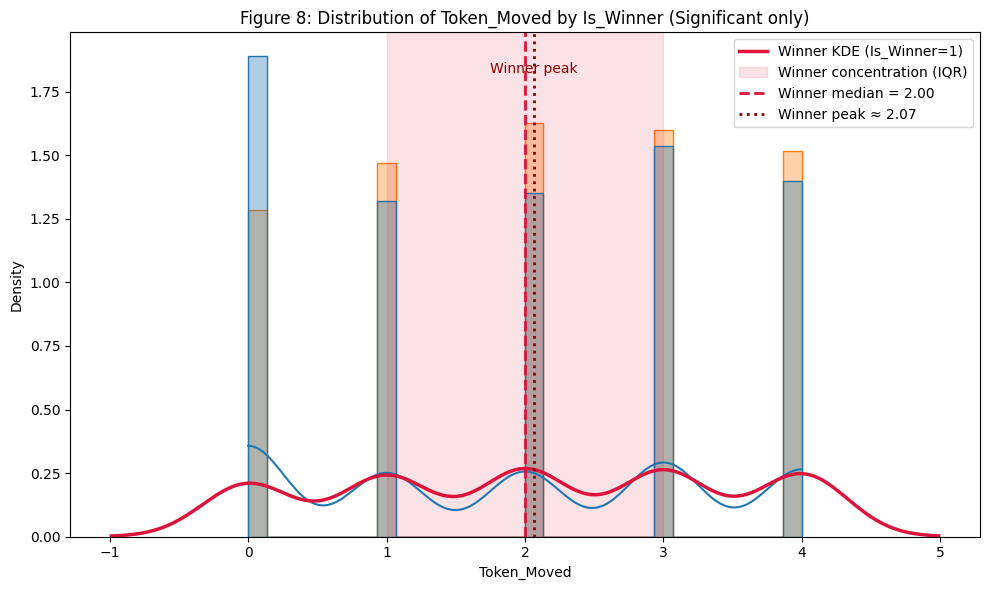

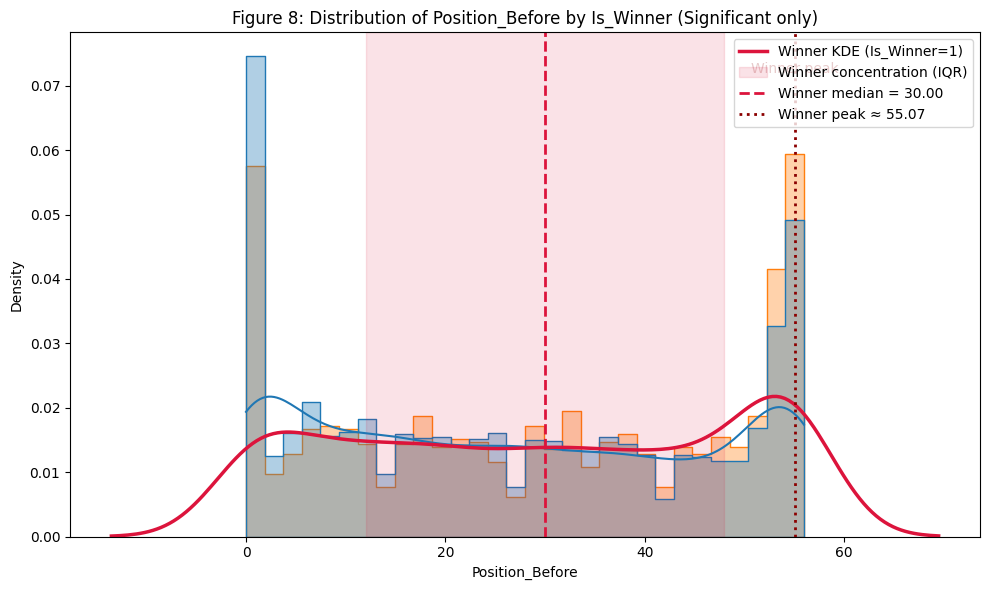

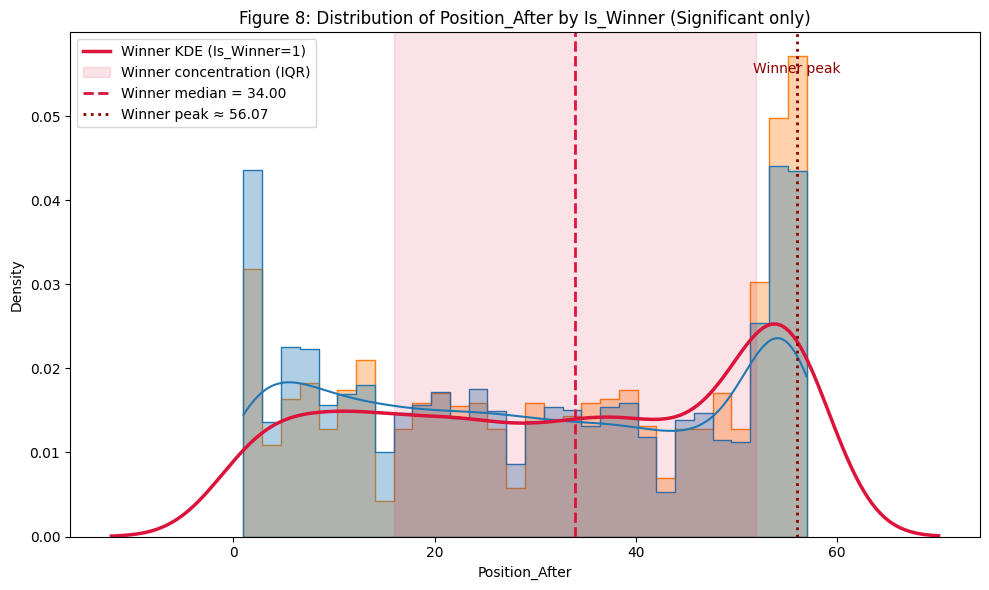

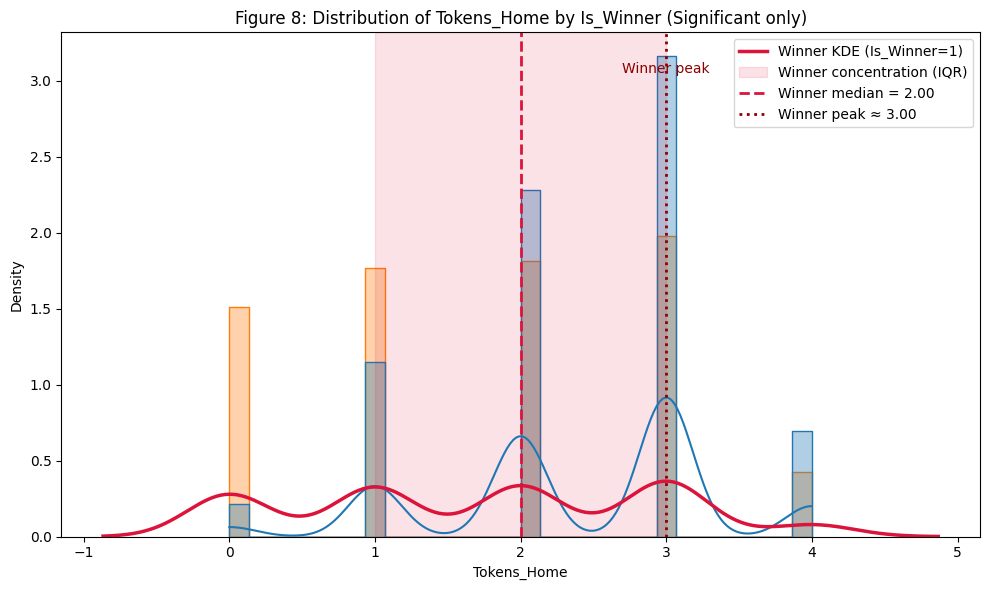

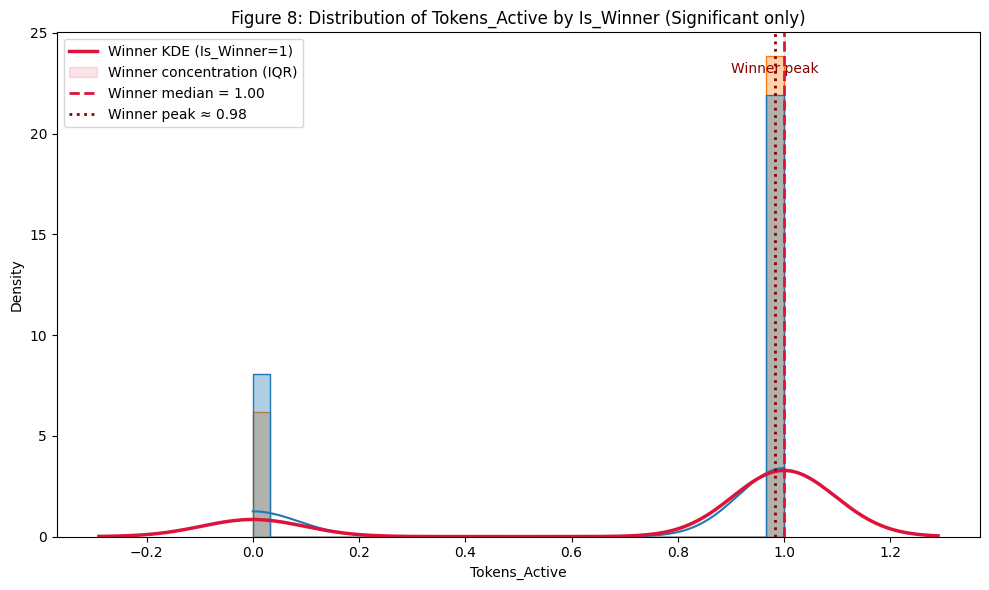

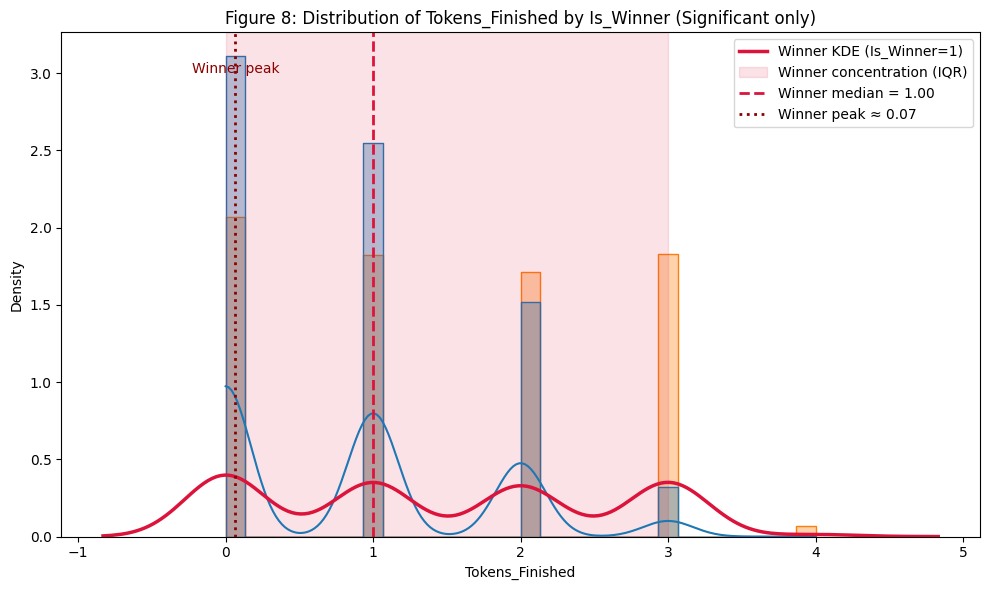

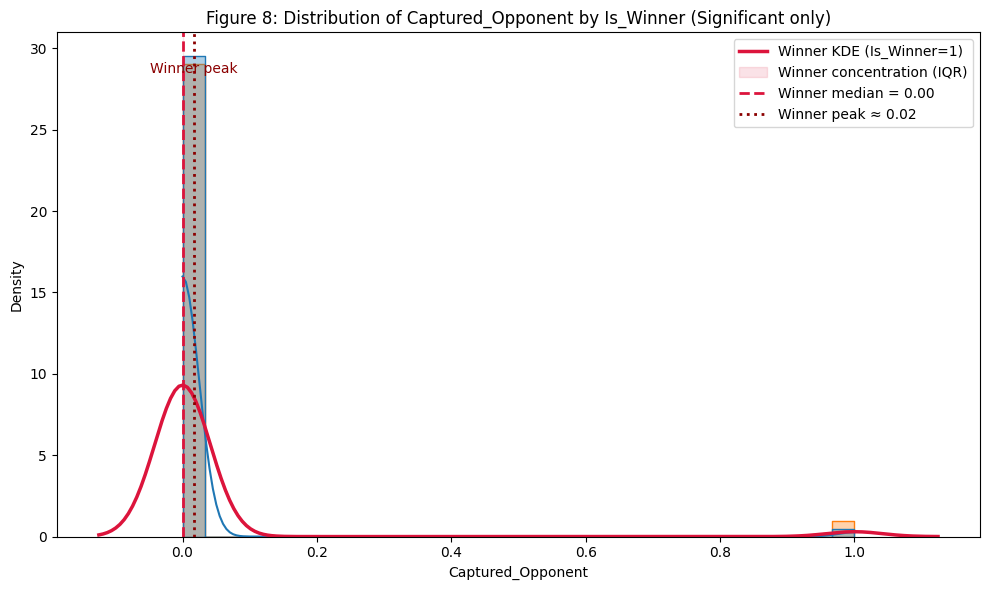

In [15]:
# Mann-Whitney U tests for numeric variables by winner status, alpha=0.05
alpha = 0.05
mwu_rows = []

group_col = 'Is_Winner'
for num_col in df_num.columns:
    if num_col in ['Game_ID', group_col]:
        continue

    subset = df[[group_col, num_col]].dropna()
    unique_groups = sorted(subset[group_col].unique())

    if len(unique_groups) != 2:
        mwu_rows.append({
            'grouping_variable': group_col,
            'numeric_variable': num_col,
            'null_hypothesis': 'Both winner-status groups have equal distributions',
            'alpha': alpha,
            'u_value': np.nan,
            'p_value': np.nan,
            'significant': False,
            'decision': 'Accept H0'
        })
        continue

    x = subset.loc[subset[group_col] == unique_groups[0], num_col]
    y = subset.loc[subset[group_col] == unique_groups[1], num_col]

    if len(x) == 0 or len(y) == 0:
        mwu_rows.append({
            'grouping_variable': group_col,
            'numeric_variable': num_col,
            'null_hypothesis': 'Both winner-status groups have equal distributions',
            'alpha': alpha,
            'u_value': np.nan,
            'p_value': np.nan,
            'significant': False,
            'decision': 'Accept H0'
        })
        continue

    result = pg.mwu(x, y, alternative='two-sided')
    p_value = result['p_val'].iloc[0]
    significant = bool(p_value < alpha)

    mwu_rows.append({
        'grouping_variable': group_col,
        'numeric_variable': num_col,
        'groups_compared': f'{unique_groups[0]} vs {unique_groups[1]}',
        'null_hypothesis': 'Both winner-status groups have equal distributions',
        'alpha': alpha,
        'u_value': result['U_val'].iloc[0],
        'p_value': p_value,
        'significant': significant,
        'decision': 'Reject H0' if significant else 'Accept H0'
    })

mwu_df = pd.DataFrame(mwu_rows)

# Always show the test result table when this cell runs
display(mwu_df)

# Visualizations: histplot + KDE only for variables with statistically significant differences
significant_vars_mwu = mwu_df.loc[mwu_df['significant'], 'numeric_variable'].tolist()

if not significant_vars_mwu:
    print('No statistically significant variables found at alpha=0.05; no histplot/KDE generated.')
else:
    for num_col in significant_vars_mwu:
        plot_df = df[[group_col, num_col]].dropna()
        if plot_df.empty:
            continue

        # Downsample for readability and speed on large datasets
        if len(plot_df) > 5000:
            plot_df = plot_df.sample(n=5000, random_state=42)

        plt.figure(figsize=(10, 6))
        sns.histplot(
            data=plot_df,
            x=num_col,
            hue=group_col,
            kde=True,
            stat='density',
            common_norm=False,
            bins=30,
            alpha=0.35,
            element='step'
        )

        # Emphasize concentration region for winners (Is_Winner == 1)
        winner_vals = plot_df.loc[plot_df[group_col] == 1, num_col]
        if len(winner_vals) > 1:
            q1, q2, q3 = winner_vals.quantile([0.25, 0.50, 0.75])
            hist_counts, bin_edges = np.histogram(winner_vals, bins=30, density=True)
            peak_idx = int(np.argmax(hist_counts))
            peak_x = (bin_edges[peak_idx] + bin_edges[peak_idx + 1]) / 2

            # Winner-focused KDE and concentration markers
            sns.kdeplot(winner_vals, color='crimson', linewidth=2.5, label='Winner KDE (Is_Winner=1)')
            plt.axvspan(q1, q3, color='crimson', alpha=0.12, label='Winner concentration (IQR)')
            plt.axvline(q2, color='crimson', linestyle='--', linewidth=2, label=f'Winner median = {q2:.2f}')
            plt.axvline(peak_x, color='darkred', linestyle=':', linewidth=2, label=f'Winner peak ≈ {peak_x:.2f}')

            ymax = plt.ylim()[1]
            plt.text(peak_x, ymax * 0.92, 'Winner peak', color='darkred', ha='center')

        plt.title(f'Figure 8: Distribution of {num_col} by {group_col} (Significant only)')
        plt.xlabel(num_col)
        plt.ylabel('Density')
        plt.legend(loc='best')
        plt.tight_layout()
        plt.show()

# Conclusion

## Summary of the analytical workflow

This notebook carried out a complete EDA and statistical testing pipeline on the 4-token-per-player Ludo simulation dataset, progressing through seven major stages:

### Step 1–3: Data loading, validation, and quality checks
- The dataset was successfully located, loaded, and validated against the expected 12-column schema.
- **Structural missingness** in `Position_Before` and `Position_After` was treated as intentional when it matched no-move turns (`Token_Moved = 0`), so these `NaN`s were preserved rather than imputed.
- Duplicate checks reported both exact duplicates and key duplicates on (`Game_ID`, `Turn`, `Player`), and outlier boxplots provided a screening view for extreme values.
- The cleaned DataFrame was saved to `ludo_dataset_cleaned.csv` for reuse in subsequent notebooks.

### Step 4: Distribution exploration
- Histograms and KDE plots showed that most variables are **non-normal, discrete, and bounded**, consistent with board-game mechanics.
- `Dice_Roll` appeared close to uniform; `Captured_Opponent` was right-skewed (rare events); `Position_Before`/`Position_After` showed spikes at 0 (home yard) and 57 (finish zone).
- The pairplot highlighted expected monotonic relationships between token-state variables: `Tokens_Home` ↔ `Tokens_Active` (negative) and `Tokens_Active` ↔ `Tokens_Finished` (negative), consistent with token-state transitions.
- Countplots showed approximate player turn balance; grouped boxplots provided a visual pre-check before formal tests.

### Step 5: Correlation analysis
- The Spearman heatmap quantified monotonic associations among token-state variables.
- `Tokens_Finished` and related progress variables are strong feature candidates to evaluate for `Is_Winner` prediction.
- Correlated feature groups (e.g., `Tokens_Home`, `Tokens_Active`, `Tokens_Finished`) may contain redundancy and should be reviewed during feature engineering.

### Steps 6a–6b: Normality testing
- Shapiro-Wilk (n ≤ 5,000) and D'Agostino-Pearson (n > 5,000) tests were applied globally and within each player group.
- Most variables and subgroups were non-normal, supporting use of non-parametric tests over ANOVA/t-test assumptions.

### Steps 6c–6d: Non-parametric group comparisons
- **Kruskal-Wallis (Player groups)**: identified numeric variables with significant between-player distribution differences. Swarmplots with per-player concentration overlays showed where differences were concentrated.
- **Mann-Whitney U (Winner vs. Non-Winner)**: identified numeric variables that distinguish winner and non-winner distributions, directly informing feature prioritisation for classification.

## Concentration parameters — reference
| Parameter | Definition | Practical meaning |
|---|---|---|
| $Q1$ (25th percentile) | Lower IQR boundary | Below this value: the bottom 25% of observations |
| $Q2$ (median) | 50th percentile | Robust central tendency; unaffected by extreme values |
| $Q3$ (75th percentile) | Upper IQR boundary | Above this value: the top 25% of observations |
| **IQR** | $Q3 - Q1$ | Width of the middle 50% concentration band |
| **Peak** ($\approx$ mode) | Midpoint of highest-density histogram bin | Most common value range; highest-density region |

## Implications for feature engineering and modelling
- **Features with significant Mann-Whitney U results** should be prioritised in the model feature set.
- **Token-state variables** (`Tokens_Finished`, `Tokens_Active`, `Tokens_Home`) capture cumulative game progress and are strong candidates for predictive signal.
- **`Captured_Opponent`** may be weak alone but useful in interaction features (e.g., with turn context).
- **`Dice_Roll`** is often weak in isolation (near-uniform), but interactions with move/position context can still add signal.
- Structural `NaN`s in position columns should be handled explicitly during feature engineering (e.g., `No_Move` flag), rather than blind fill/drop operations.